# Feature analysis — price_momentum (per-exchange momentum, short & long)

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it. It is a clone of the feature-analysis template (worked example there:
`price_dislocation`), with **`price_momentum`** swapped in and built **per exchange**.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

**The feature.** `price_momentum` is **per-exchange drift**: how strongly a venue's own mid-price
has been *trending* over a recent window, on the trade clock. We build the same momentum atom for
**every** venue (byb's own leg *and* the cross-venue okx/bin legs) and keep them all — momentum on
byb is the direct signal; momentum on okx/bin is a **cross-venue lead** test (does another venue's
trend lead byb's next move?). Three forms are studied, all from one atom `signed_ret_N = EMA(Δlog mid)`:

1. **signed_return_momentum** — the σ-normalised drift `signed_ret_N / (σ_ev·k)`. RAW it is a *level
   scaled by returns*, so we **build it raw, measure its regime-invariance scale, and divide by `σ_ev`
   only if it fails** (never assumed — §5/§6).
2. **trend_efficiency_ratio** — `EMA(Δlog mid) / EMA(|Δlog mid|) ∈ [−1,1]` (Kaufman efficiency: net
   move ÷ path length). A **bounded ratio**, invariant **raw**.
3. **momentum_spread** — `signed_ret_fast − signed_ret_slow`, a **trade-clock MACD** (fast trend minus
   slow trend), the freshest-acceleration read.

**A feature is "done" when two checks pass:**
- **The oracle (§4)** — the code really computes what we think it does (bit-exact, every venue).
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo of "the
  market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what time-scale*.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`. **This is `price_momentum`'s home head** — momentum is a directional signal.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime and you want it gone, dividing
by the yardstick is **one option** for removing it (only *when applicable* — you can't always
divide the regime out of a feature). Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`)
but **updated between trades** — they react to every byb mid-move, so they read live at every
instant. They use one fixed span, `YARDSTICK_N` (any feature may use that span too). (`σ_ev` is
the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many non-move
trades cancel out; `λ_ev` is a ratio of two EMAs — the exp-weighted byb move-count `W` (the same
`W` that is `σ_ev`'s denominator) ÷ the exp-weighted seconds-per-trade = byb's moves per second.) Like every average here, they live
on the trade-tick clock — never wall-clock or a hard window.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*,
one per possible move-count: "if `k` moves happen, here's the spread of the total price
change" (call it `D_k`). The rate head gives the probability of each count, `P(K = k)`. The
100 ms move is the two **mixed** — for every count `k`, take the price head's `k`-move
distribution, weight it by the rate head's probability of exactly `k` moves, and sum:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's
`D_k` sets the shape. This is why a feature that predicts the *count* (rate head) and one that
predicts the *per-move direction* (price head) are both useful: they feed the two factors that
multiply together.

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns
over a fixed clock-time window look messy, but become well-behaved once you condition on the
*number* of events. So modelling the event count and the per-event move separately, then mixing
them, is a principled decomposition — not just a convenient one.

Every feature here feeds one or both heads, and borrows the matching yardstick when it needs
to be made comparable across markets. Two questions recur below: does a feature's *signed*
value predict the move (price head), and does its *magnitude* predict how many moves come
(rate head)? Those are diagnostics — the model is fed the **signed** feature for *both* heads,
and the rate head learns the magnitude (and how features cancel or reinforce) on its own.

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build
  the feature the same way for every exchange and keep them all. `price_momentum` is built per
  venue (each off its *own* mid-moves) for exactly this reason.
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads (often the most informative ones). Keep all; let the model weight them.
- **Don't pool exchanges by default.** Pooling can blur the cross-exchange structure. For a
  poolable feature, first check per-exchange vs single vs pooled across time-scales (§9).
- **Don't normalize reflexively.** Divide volatility or rate out of a feature *only when it
  needs it* — a ratio or imbalance is already comparable across markets. (The efficiency ratio is
  bounded and needs none; the signed-drift level is **measured** and normalised only if it fails.)
- **Don't invent your own vol/rate scale.** When you do normalize, use the model's yardstick
  (`σ_ev` or `λ_ev`), so the feature shares units with the target.
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — else
  it may just be re-reporting "the market is volatile."
- **Don't ship a feature without the oracle** (§4) matching a dead-simple independent version.
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **NEVER a hard / boxcar / rolling window.** No rolling max/min (Donchian), no fixed-N lookback
  buffer. A "range" / "breakout" must be **EMA-based** (a Bollinger-style z, `(x − ema)/√(ema(x²)−ema(x)²)`).
  Every momentum atom here is a **trade-clock EMA of the log-return**, O(1) state, never a window.
- **Don't over-transform for the network.** Pick the lightest reshaping that works.

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism for why it should work, and what
  would prove it wrong.
- **Do make every average a trade-tick EMA.** *Every* smoother in the pipeline — the momentum
  legs, `σ_ev`, `λ_ev`, any rolling statistic — is an exponential moving average **decayed once
  per trade-timestamp** (`α = 2/(span+1)`) yet **updated on every live event between trades**, **never** a wall-clock
  average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (one scalar
  per average, no ring buffers) and bit-identical online vs offline. Establish and validate the
  convention against a plain one-event-at-a-time loop on a real block — exactly as
  `notebooks/03_ema_clock_validation.ipynb` does, and as the §4 oracle re-checks here.
- **Do make every EMA react to *every* relevant event — never let it read a stale state.** An EMA's
  *decay* lives on the trade clock, but it must *update* on every event that can change its value,
  **even between trade ticks**: a momentum leg injects each fresh mid-move the instant it lands. A
  value that ignores the moves since the last trade is **stale** — wrong, and a silent source of lag.
- **Do treat all records sharing a timestamp as ONE event, not a sequence.** A burst of book updates
  and trades stamped at the *exact same instant* did not arrive in an order — they are **one event
  carrying many pieces of data**. Apply them all, *then* register a single update: one mid, one move,
  one refresh. Imposing an order on a single instant invents motion that never happened *in time* —
  phantom intra-instant round-trips — which is **wrong** for any path-summing quantity: a venue's
  momentum sums signed mid-*moves*, so N simultaneous records would fabricate N−1 fake moves. The
  decay clock is the only place order matters — and a timestamp with trades advances it **once**.
- **Do always read the *freshest* value — never freeze on the last trade's.** An EMA decays once
  per trade-timestamp (that fixes its memory in trade-count), but its *read* must use the latest
  mid-move: fold in the partial epoch of moves since the last trade — never the stale snapshot frozen
  at the last trade tick. Keep the two clocks separate: refresh the *read* on every move, but keep the
  *decay/weighting* on the trade clock.
- **Do test against both heads — but feed both the *signed* feature.** Check whether the
  signed feature predicts *direction* (price head — momentum's home) and whether its *magnitude*
  predicts *intensity* (rate head). Those are diagnostics — in the model, feed the **signed**
  feature to *both* heads, never a pre-computed `|feature|`. The rate head learns the magnitude
  itself, *and* learns that a +trend on one venue can cancel a −trend on another.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future) — a single split is only a faster screen.
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads.
- **Do prove regime-invariance with the scale gate — never assume it.** A usable feature reads the
  *same* in calm and wild markets; the test is its **measured scale across volatility buckets** (§5's
  normaliser), and that is a **hard** gate (`<~3×`). A raw **level** (a σ-scaled drift) usually fails
  it; a **bounded / normalised** form passes. The efficiency ratio is bounded ([−1,1]); the signed-drift
  level is the one we **measure** and normalise (by `σ_ev`) only if it fails. Measure, don't assume.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.
If there's no story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | how strongly each venue's own mid has been *trending* recently (its drift), short & long scale |
| **feeds** | both heads — but **price head (direction) is home**: momentum is a directional signal. Rate head (intensity) is a diagnostic. Both are fed the *signed* feature |
| **predicts** | byb's mid-price 100 ms from now |

**The idea.** Take a venue's log mid-price increments `Δlog mid` and smooth them on the trade clock:
`signed_ret_N = EMA(Δlog mid, N)` is the recent **signed drift** — positive when the venue has been
climbing, negative when falling. Three reads of it:
- divide by `σ_ev` → **signed_return_momentum**, the drift in volatility units;
- divide by `EMA(|Δlog mid|, N)` → **trend_efficiency_ratio** ∈ [−1,1], how *straight* the path was
  (Kaufman's efficiency ratio: net move ÷ total distance travelled — 1 = a clean trend, 0 = chop);
- subtract a slower drift → **momentum_spread** = `signed_ret_fast − signed_ret_slow`, a MACD that
  fires when the trend *accelerates*.

**Why it should work.** Order flow arrives in bursts and prices have short-horizon
**autocorrelation** (continuation): a venue that has just ticked up tends to tick up again over the
next few moves, as a large order keeps sweeping or informed flow keeps pushing one side. So a venue's
recent drift predicts a little more of the same — *continuation* (positive IC). The opposite,
**mean-reversion** (a stretched move snaps back, negative IC), is equally plausible at these horizons —
which way it goes, and at which scale, is precisely what we measure. For the **cross-venue** legs the
mechanism is a **lead/lag**: if okx/bin trends a beat before byb, their momentum predicts byb's
catch-up. (We don't pin the exact lag here; "a beat" is roughly tens of milliseconds.)

**What would disprove it.** No predictive power at any time-scale for any venue, or power that is
purely the move *already underway* at the anchor (a contemporaneous echo, dead by δ>0 — measured in
the lifetime sweep), or power that vanishes once we control for the volatility/rate regime.

> **No fixed leader.** It's tempting to call one venue "the leader." Don't — leadership moves around.
> Build the feature *the same way for every venue and keep them all*; the cross-venue legs are tested
> honestly in §6/§9, never assumed to lead.

## Choosing the EMA — the part that's easy to get silently wrong

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates on every mid-move in between**, so a read between trades is
never stale. That looks like plumbing, but two choices decide whether the EMA is even *correct*, and a
wrong choice fails **silently**. So make both deliberately, and let the §4 oracle catch you if you slip.

**Choice 1 — which EMA, and how you read it.** `signed_ret_N` is a **smoothed flow of increments**:
the quantity `Δlog mid` lands only when a venue's mid *moves*, and we want the trade-weighted decayed
**sum** of those increments (a velocity), read with a **live front** that folds in the moves since the
last trade. So each momentum leg is a decayed-sum EMA: inject `α·Δlog` on each mid-move, decay by
`(1−α)` on each trade tick, read `committed + α·(increments since the last trade)`. `abs_ret_N` is the
identical machine fed `|Δlog mid|` — **same events, same weights**, which is what makes the efficiency
ratio `signed/abs` provably bounded in `[−1,1]`. (The yardstick `σ_ev` is a *different* shape — a
self-normalising `E/W` mean of squared moves — because there we want a per-move RMS, not a sum.)

**Choice 2 — *when* you push a value in** (the injection clock — separate from the decay clock). Decay
is always once per trade-timestamp; the **injection** is once per **real mid-move**, skipping the many
non-move trades. Pushing a `0` on a non-move would not change a *sum* leg (0 adds nothing) — but it is
the move detection, not a zero-fill, that keeps the read honest: a momentum leg reacts to **mid-moves**,
not to trade arrivals or quote churn. Two between-trade rules keep the read correct:

- **React to every mid-move, and read the freshest value.** Decay rides the trade clock, but the leg
  must *update* on every mid-move and the read must fold the moves since the last trade — never a stale
  snapshot. (Fresh costs nothing for a 100 ms target and never lags; stale silently lags when trades
  are sparse.)
- **Records sharing a timestamp are ONE event** — collapse same-timestamp mid updates to the final mid
  (one move), apply them, then register a single refresh and at most one decay. Treating them as a
  sequence fabricates intra-instant round-trips that never happened in time. (The §4 oracle enforces both.)

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed; no peeking at the future. (A stray
forward-fill is the usual way to break this by accident.)

**Measured on the trade clock** — markets alternate busy and quiet, so we count progress in *trades*
(one tick per trade-timestamp on any exchange — simultaneous prints are one tick) rather than in
clock-seconds. Book/mid updates between trades refresh what the EMA *reads*, but they do **not** advance
the clock — only a trade does, decaying each EMA once. **Never a hard window** — no rolling max/min, no
fixed-N buffer; the "lookback" is the EMA's span `N`, an exponential memory, not a boxcar.

**Comparable across calm and wild markets** — *measured, not assumed*. The three forms differ exactly
here, which is the heart of the RAW-FIRST rule:

**2a — The atom and the three forms** (one line each):

- atom: `signed_ret_N(ex) = EMA(Δlog mid, N)` — a venue's smoothed signed drift (a velocity).
  `abs_ret_N(ex) = EMA(|Δlog mid|, N)` — its path length (same events/weights).
- **(1) signed_return_momentum = `signed_ret_N / (σ_ev · k)`** — drift in volatility units. RAW, the
  bare `signed_ret_N` is a *level scaled by returns* (bigger in volatile markets), so it is the form we
  **suspect** is non-invariant. We **build it raw, MEASURE its scale across vol buckets (§5/§6), and
  divide by `σ_ev` ONLY if it fails** — never assumed. (`k` is a fixed constant — it drops out of every
  rank correlation — so the decision is purely "raw vs `/σ_ev`".)
- **(2) trend_efficiency_ratio = `signed_ret_N / abs_ret_N` ∈ [−1,1]** — Kaufman's efficiency ratio:
  net move ÷ path length. A **bounded ratio**, regime-invariant **raw** (no division needed) — we
  *measure* that too, but the prior is strong.
- **(3) momentum_spread = `signed_ret_fast − signed_ret_slow`** — a trade-clock MACD. A difference of
  two σ-scaled-ish drifts; we measure its scale and normalise by `σ_ev` if needed.

**2b — The EMAs we use, and how they update** (applying the two choices above):

- **Each momentum leg** (`signed_ret_N`, `abs_ret_N`) is a **decayed-sum EMA on the trade clock**:
  inject `α·Δlog` (or `α·|Δlog|`) on every venue mid-move, decay by `(1−α)` on each trade tick, and read
  the **live front** `committed + α·(increments since the last trade)`. `N = 1` sets `α = 1` (the leg
  collapses to the freshest increment, no smoothing). `signed_ret_N` and `abs_ret_N` share the move
  detection and weights, so `|signed_ret_N| ≤ abs_ret_N` always → the ratio lives in `[−1,1]`.
- **`σ_ev` and `λ_ev`** (the yardsticks) are a **sparse flow** read as `E/W`: push `byb_return²` on a
  real byb mid-move, decay every trade, read `σ_ev = √(E/W)` = RMS move *per move*. Dividing by `W`
  removes the move *rate* and a fresh EMA's start-up bias, leaving a per-move volatility comparable in
  calm and busy markets.

Both reads obey the two between-trade rules. §3 builds exactly this **per venue**; §4 re-derives it from
raw events with an independent streaming state machine and confirms it **bit-exact** for every venue.

The cell below loads the data, builds the shared trade clock, each venue's mid-move stream (the sparse
flow the momentum legs are built from), and **both byb yardsticks** as `E/W` flows, span `YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict
EXCHANGES   = ["byb", "okx", "bin"]              # price_momentum is built per venue (each off its OWN mid-moves); keep ALL (no fixed leader)
OTHERS      = ["okx", "bin"]                     # the cross-venue legs (each predicting byb) — byb's own leg is the direct signal
# freshest mid per exchange. front_levels = raw best-bid/ask snapshots; merged_levels = those snapshots fused
# with trades for a fresher mid. byb/okx use merged_levels; bin MUST use front_levels — merged_levels is DISALLOWED for
# bin perp in boba.io (it raises). This is a policy, not a tuning choice.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
FAST        = [1, 10, 50, 200]                   # fast-EMA momentum spans to sweep (1 = no smoothing, the freshest increment)
SLOW        = [100, 500, 2000, 8000]             # slow-EMA momentum spans (each must exceed the fast one)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH byb yardsticks (σ_ev, λ_ev): a trade-tick EMA (α=2/(N+1)) — fixed, used for every feature
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load each exchange's mid-price stream (rows already arrive in time order)
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in EXCHANGES}

# the trade clock: one tick per trade-TIMESTAMP. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_ts = []
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"shared trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# --- per-venue mid-move stream: the sparse flow EACH venue's momentum legs are built from ---
def move_stream(ex):                                                              # build THIS venue's Δlog flow (+ for byb the r^2 / count)
    rx0, mid0 = mids[ex]
    keep = np.concatenate([rx0[1:] != rx0[:-1], [True]])                         # collapse same-TIMESTAMP rows to ONE update (the final mid): simultaneous events are not a sequence
    rx, mid = rx0[keep], mid0[keep]
    lm = np.log(mid)
    dlr = np.empty_like(lm); dlr[0] = 0.0; dlr[1:] = np.diff(lm)                  # Δlog mid per timestamp (signed increment)
    mv = dlr != 0.0                                                              # a REAL mid-move: ONE per timestamp where the mid changed
    return rx[mv], dlr[mv], rx, mid, np.concatenate([[0.0], np.cumsum(mv.astype(float))])
MV = {}                                                                          # ex -> (move_rx, move_dlog, collapsed_rx, collapsed_mid, cum_moves)
for ex in EXCHANGES:
    MV[ex] = move_stream(ex)
byb_rx, byb_mid, cum_mv = MV["byb"][2], MV["byb"][3], MV["byb"][4]               # byb's collapsed mid + running move count (rate-head target)

byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades (per-trade)
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_sum_at(anchors, mv_rx, val, span):   # decayed SUM of `val` over a venue's MOVE stream, decayed once per trade-timestamp, read AT each anchor (partial epoch since last trade folded in -> fresh)
    a = 2.0 / (span + 1.0)                       # this returns the running E (decayed sum); momentum reads E directly, σ_ev divides by W
    k = np.searchsorted(merged_ts, mv_rx, "left")                               # trades strictly before each move (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed sum just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the move stream (the partial epoch)
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def sigma_ev_at(ex, anchors, span):         # σ_ev[ex] at `span`: √(E/W) over THAT VENUE's move stream
    mv_rx, mv_d = MV[ex][0], MV[ex][1]
    e_sq = _flow_sum_at(anchors, mv_rx, mv_d ** 2, span)         # E: exp-weighted squared moves
    e_mv = _flow_sum_at(anchors, mv_rx, np.ones(mv_d.size), span)  # W: exp-weighted move count
    return np.sqrt(e_sq / np.maximum(e_mv, 1e-12))               # RMS mid-move per move (E/W)
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — BYB's model yardsticks (for controls + targets)
    mv_rx, mv_d = MV["byb"][0], MV["byb"][1]
    e_sq = _flow_sum_at(anchors, mv_rx, mv_d ** 2, span)
    e_mv = _flow_sum_at(anchors, mv_rx, np.ones(mv_d.size), span)
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (per-trade, held flat between trades)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second
    return sig, lam
for ex in EXCHANGES:
    print(f"  {ex}: {int(MV[ex][0].size):,} mid-moves of {int(MV[ex][2].size):,} updates carry a real move (its Δlog flow)")
print(f"yardsticks + all momentum legs: react to every relevant mid-move; decay on the ONE shared trade clock")

shared trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints


  byb: 147,238 mid-moves of 1,726,152 updates carry a real move (its Δlog flow)
  okx: 128,848 mid-moves of 2,604,805 updates carry a real move (its Δlog flow)
  bin: 179,338 mid-moves of 9,350,160 updates carry a real move (its Δlog flow)
yardsticks + all momentum legs: react to every relevant mid-move; decay on the ONE shared trade clock


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a
streaming version that does constant work per trade (no growing buffers). They have to agree,
which §4 checks **for every venue**.

Here we lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; note
that adjacent 100 ms outcome windows still overlap ~50%, so neighbouring samples are correlated,
which is exactly why §5's walk-forward gate uses an embargo), read byb's actual move over the
next 100 ms (the thing we're predicting), and compute each `price_momentum` form for **each venue**
at each grid point.

In [2]:
# evaluation grid (causal) + forward targets (price head in σ-units; rate head in λ-units)
WARMUP = 5 * max(YARDSTICK_N, max(SLOW))   # enough trades for the slowest EMA/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)   # both BYB yardsticks at each grid point (span-YARDSTICK_N trade-tick EMA)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target (momentum's HOME): byb's 100 ms log-return ÷ σ_ev
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # the price head's target (σ-units)

# the momentum ATOMS, per venue, read at every grid anchor. CACHE per (venue, span, kind) — every span appears in many fast/slow pairs.
_sret_cache, _aret_cache = {}, {}
def signed_ret(ex, span):                                          # EMA(Δlog mid, span): smoothed signed drift (a decayed SUM of increments, live-front read)
    if (ex, span) not in _sret_cache:
        _sret_cache[(ex, span)] = _flow_sum_at(anchor_ts, MV[ex][0], MV[ex][1], span)
    return _sret_cache[(ex, span)]
def abs_ret(ex, span):                                             # EMA(|Δlog mid|, span): smoothed path length (SAME events/weights as signed_ret -> ratio in [-1,1])
    if (ex, span) not in _aret_cache:
        _aret_cache[(ex, span)] = _flow_sum_at(anchor_ts, MV[ex][0], np.abs(MV[ex][1]), span)
    return _aret_cache[(ex, span)]

K_NORM = 1.0   # a fixed constant in signed_return_momentum (drops out of every rank-IC); the only real choice is raw vs /σ_ev (decided by the §5/§6 scale gate)
# --- the three forms (RAW signed-drift first; the §5/§6 scale gate decides whether to divide by σ_ev) ---
def signed_return_raw(ex, span):                   # (1) RAW: the bare σ-scale-bearing drift level — we MEASURE its regime-invariance, then normalise IF it fails
    return signed_ret(ex, span)
def signed_return_momentum(ex, span):              # (1) NORMALISED candidate: drift ÷ (σ_ev·k) — used only if the raw form fails the scale gate
    return signed_ret(ex, span) / (sigma_at_anchor * K_NORM)
def trend_efficiency_ratio(ex, span):              # (2) Kaufman efficiency: net move ÷ path length ∈ [−1,1] — bounded, invariant RAW
    return signed_ret(ex, span) / np.maximum(abs_ret(ex, span), 1e-300)
def momentum_spread(ex, n_fast, n_slow):           # (3) trade-clock MACD: fast drift − slow drift (the freshest-acceleration read)
    return signed_ret(ex, n_fast) - signed_ret(ex, n_slow)
print(f"grid: {len(anchor_ts):,} anchors")
for ex in EXCHANGES:
    print(f"  {ex}: signed_ret(50) median {np.nanmedian(signed_ret(ex, 50)):+.2e},  efficiency(50) median {np.nanmedian(trend_efficiency_ratio(ex, 50)):+.3f} (∈[−1,1])")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors


  byb: signed_ret(50) median +4.73e-09,  efficiency(50) median +0.061 (∈[−1,1])


  okx: signed_ret(50) median +2.36e-10,  efficiency(50) median +0.127 (∈[−1,1])


  bin: signed_ret(50) median +2.11e-09,  efficiency(50) median +0.307 (∈[−1,1])


## 4. Check the code is right — the oracle (a production-style streaming build, per venue)

**Non-negotiable.** Reproduce the feature with a second, **independent** implementation (plain numpy
scalars, **no production helpers, no shared code** with §3's vectorized path) and confirm the two agree
on real data — **for every per-exchange leg**. The oracle is the **production** reference: an O(1) state
machine you push **raw events** into — `on_book(...)` for a top-of-book update, `on_trade(...)` for a
trade — and read the current feature from `value()`. State is a handful of scalar EMAs per venue (the
fast/slow signed-drift legs, the abs-drift legs, and byb's two `σ_ev` E/W accumulators) — no buffers, no
history, independent of how long it runs.

**The design:**
- Fed **only raw events**, each tagged by its full listing and keyed by it, so a perp and a spot on one
  exchange stay separate books. Each builder builds its target venue's mid **itself** (merged venues fuse
  trades into the book by newest-exchange-time; bin is book-only) so the live mid matches the analysis mid.
- Events sharing a **timestamp are one event**: the driver applies them all, then calls **`refresh()`
  once** — which detects a target-venue mid-*move*, injects `α·Δlog` into the signed legs and `α·|Δlog|`
  into the abs legs (and byb's `r²` into `σ_ev`), then advances the clock **at most once** (decays every
  leg) and only if a trade landed. A book-only instant moves the mid without advancing the clock.
- `value()` returns each of the three forms via the live front — current at the instant it's read.

We feed the **whole raw stream** — every venue's book updates and trades — into **all three** builders
in lock-step and read each venue's `price_momentum` at each grid anchor. If every online build reproduces
§3's vectorized feature on real data, all are right.

**Coverage that matters.** Two things make this a genuine check, not a thin slice: (1) we validate the
**shipped span** — `N=10` (the headline directional pick of §6) and the slow MACD leg `8000` — not an
arbitrary 50/500 pair; and (2) we validate on a **dispersed window deep in the block** (anchors
≈800k–880k of 1.7M), not the first-40k start-of-block prefix whose contiguous early timing is
unrepresentative. The state machine cannot skip events, so we replay a generous lead-in to warm every
EMA/yardstick, then diff only over the window's ~80k anchors — exercising arbitrary-nanosecond event
timing far from warmup. (The vectorized §3 build, by contrast, covers all 1.7M anchors at every span;
the bit-exact agreement here plus §3's lifetime/gate sweeps over the full grid is the full coverage.)

In [3]:
import boba.io as io
import math

class LiveMomentum:
    # Pure feature state machine for ONE target venue — INDEPENDENT of §3 (plain float scalars, no boba.ema, no shared code).
    # Each momentum leg is a decayed-SUM EMA with a live front:  inject α·Δlog on a real target mid-move; decay by (1−α) on a
    # trade tick; read = committed + α·(Δlog since the last trade). signed legs are fed Δlog, abs legs |Δlog| (same events/weights).
    # σ_ev (byb only) is its own E/W: inject r² and weight 1 on a move, decay both on a trade, read √(E/W). on_book/on_trade only
    # mutate this venue's bid/ask; the driver calls refresh() ONCE per timestamp (detect move -> inject; if a trade landed -> one decay).
    # The mid is built INSIDE (never read from merged_levels): merged venues fuse trades by newest-exchange-time; bin book-only.
    def __init__(self, target, n_fast, n_slow, fuse_trades):
        self.target = target
        self.fuse_trades = set(fuse_trades)
        self.bid = {}; self.bid_t = {}; self.ask = {}; self.ask_t = {}     # newest-by-exchange-time top-of-book, keyed by listing
        self.af = 2.0 / (n_fast + 1.0); self.as_ = 2.0 / (n_slow + 1.0)     # fast/slow α
        # decayed-sum legs (committed) + the live-front partial epoch since the last trade
        self.cf_s = 0.0; self.cs_s = 0.0; self.cf_a = 0.0; self.cs_a = 0.0  # committed: fast/slow signed, fast/slow abs
        self.part_s = 0.0; self.part_a = 0.0                               # Σ Δlog / Σ |Δlog| since the last trade (the live front)
        # byb σ_ev as E/W (for signed_return_momentum normalisation)
        self.av = 2.0 / (YARDSTICK_VOL_SPAN + 1.0)
        self.vE = 0.0; self.vW = 0.0                                        # committed E (Σ α r²) and W (Σ α 1)
        self.part_vE = 0.0; self.part_vW = 0.0                             # partial epoch for σ_ev's live front
        self.prev = None                                                   # target's last log-mid, to detect a real move
        self.was_trade_present = False

    def _side(self, listing, is_ask, px, t):                              # keep this listing-side's newest-by-exchange-time price
        held_t = (self.ask_t if is_ask else self.bid_t)
        if t > held_t.get(listing, -1):
            (self.ask if is_ask else self.bid)[listing] = px; held_t[listing] = t

    def _mid(self, listing):
        b, a = self.bid.get(listing), self.ask.get(listing)
        return None if b is None or a is None else 0.5 * (b + a)

    def refresh(self):                                                    # ONE per TIMESTAMP: inject on a real target move, then advance the clock AT MOST ONCE (only if a trade landed)
        traded, self.was_trade_present = self.was_trade_present, False
        tgt = self._mid(self.target)
        if tgt is None: return
        lt = math.log(tgt)
        if self.prev is not None and lt != self.prev:
            d = lt - self.prev                                            # Δlog mid (signed) for THIS move
            self.part_s += d                                              # accumulate the live-front partial epoch (RAW sum; α applied at read/commit)
            self.part_a += abs(d)
            self.part_vE += d * d; self.part_vW += 1.0                    # σ_ev partial epoch (r², count)
        self.prev = lt
        if traded: self.tick()                                            # a trade landed -> advance the clock exactly once

    def on_book(self, listing, t, bid, ask):                              # BBO update -> mutate that listing's mid only
        if listing in self.fuse_trades:
            self._side(listing, False, bid, t); self._side(listing, True, ask, t)
        else:
            self.bid[listing] = bid; self.ask[listing] = ask

    def on_trade(self, listing, t, px, lifts_ask):                       # trade -> fold into the mid (merged listings) and flag the timestamp as traded
        if listing in self.fuse_trades: self._side(listing, lifts_ask, px, t)
        self.was_trade_present = True

    def tick(self):                                                       # advance the trade clock ONE step: commit the epoch into each leg (α·sum), then decay by (1−α)
        # committed_after = (1−α)·committed + α·(1−α)·epoch  ==  (1−α)·(committed + α·epoch)
        self.cf_s = (1.0 - self.af)  * (self.cf_s + self.af  * self.part_s)
        self.cs_s = (1.0 - self.as_) * (self.cs_s + self.as_ * self.part_s)
        self.cf_a = (1.0 - self.af)  * (self.cf_a + self.af  * self.part_a)
        self.cs_a = (1.0 - self.as_) * (self.cs_a + self.as_ * self.part_a)
        self.vE   = (1.0 - self.av)  * (self.vE   + self.av  * self.part_vE)
        self.vW   = (1.0 - self.av)  * (self.vW   + self.av  * self.part_vW)
        self.part_s = 0.0; self.part_a = 0.0; self.part_vE = 0.0; self.part_vW = 0.0

    def _legs(self):                                                      # live-front reads: committed + α·partial (the moves since the last trade)
        fs = self.cf_s + self.af  * self.part_s                           # signed_ret fast
        ss = self.cs_s + self.as_ * self.part_s                           # signed_ret slow
        fa = self.cf_a + self.af  * self.part_a                           # abs_ret fast
        sa = self.cs_a + self.as_ * self.part_a                           # abs_ret slow
        sig = None
        wE = self.vE + self.av * self.part_vE; wW = self.vW + self.av * self.part_vW
        if wW > 0.0: sig = math.sqrt(wE / wW)
        return fs, ss, fa, sa, sig

    def sigma(self):                                                      # this venue's live σ_ev = √(E/W) (byb's is the model yardstick used to normalise EVERY venue's drift)
        _, _, _, _, sig = self._legs()
        return sig

    def value(self):                                                      # raw legs via the live front; signed_norm is applied in the driver with BYB's σ_ev (the model yardstick)
        fs, ss, fa, sa, sig = self._legs()
        eff = (fs / fa) if fa > 0.0 else float("nan")                         # trend_efficiency_ratio = signed_ret_fast / abs_ret_fast ∈ [−1,1]
        return {"signed_raw": fs, "efficiency": eff, "spread": fs - ss}

# --- gather the WHOLE raw stream (every venue's book updates + trades) over a slice; no merged_levels anywhere ---
YARDSTICK_VOL_SPAN = YARDSTICK_N
# Validate the SHIPPED span (N=10, the headline directional pick) and the slow MACD leg (8000), and do it on a
# DISPERSED window — NOT the first-40k contiguous prefix (a start-of-block slice with unrepresentative timing). We
# stream a contiguous window deep in the block (events MUST be replayed contiguously — the state machine can't skip),
# warming the builder over a lead-in run, then validate only over the window's anchors. NF=10 IS the shipped span.
NF, NS = 10, 8000                                  # shipped headline fast span (10) + the slow MACD leg (8000)
A_LO = min(800_000, max(0, len(anchor_ts) - 80_000))           # window START anchor index — deep in the block (dispersed from the start)
A_HI = min(A_LO + 80_000, len(anchor_ts) - 1)                  # window END anchor index (~80k anchors validated)
# The EMA/yardstick memory is in TRADE-TICKS, not wall-clock — σ_ev's span is 10000 trades, so a fixed-seconds lead-in
# under-warms it. Replay from the wall-clock time of the trade-tick that is WARM_TICKS *trades* before A_LO's tick, so
# every span (incl. σ_ev at YARDSTICK_N) is fully converged by A_LO — matching §3's start-of-block WARMUP convention.
WARM_TICKS = 22 * max(YARDSTICK_N, NS)                         # trade-ticks of lead-in (~22 e-foldings of the slowest memory, σ_ev span) so the streaming σ_ev converges to FLOAT precision -> signed_norm is bit-exact too, not just signed_raw
tick_lo = int(tick_at_anchor[A_LO])                           # the trade-clock tick at A_LO
warm_tick = max(0, tick_lo - WARM_TICKS)
lo_cut  = int(anchor_ts[A_LO]); hi_cut = int(anchor_ts[A_HI])  # wall-clock window bounds
warm_ts = int(merged_ts[warm_tick])                           # replay from this trade's wall-clock time -> state converged by A_LO
LISTINGS = [f"{ex}_{COIN}" for ex in ("byb", "okx", "bin")] # 0=byb, 1=okx, 2=bin — integer codes keep the event arrays numeric & fast
cols = {k: [] for k in "rx kind lid t a b".split()}
def add(rx, kind, lid, t, a, b):                   # stage one source's events (kept within [warm_ts, hi_cut])
    m = (rx >= warm_ts) & (rx <= hi_cut); n = int(m.sum())
    cols["rx"].append(rx[m]); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    cols["t"].append(t[m]); cols["a"].append(a[m].astype(float)); cols["b"].append(b[m].astype(float))
for lid, ex in ((0, "byb"), (1, "okx")):           # merged-mid venues: raw front_levels (bid/ask + exchange_time), they fuse trades
    fl = load_block(block, f"{ex}_{COIN}", "front_levels").select("rx_time", "exchange_time", "bid_prc", "ask_prc").drop_nulls()
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid, fl["exchange_time"].cast(pl.Int64).to_numpy(), fl["bid_prc"].to_numpy(), fl["ask_prc"].to_numpy())
brx, bmid = mids["bin"]                             # book-only venue: bin's front_levels mid (already loaded in §2); fed as bid=ask=mid
add(brx, 0, 2, brx, bmid, bmid)
for lid, ex in ((2, "bin"), (0, "byb"), (1, "okx")):   # trades from EVERY venue tick the shared clock; byb/okx also fuse their mid
    td = load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "exchange_time", "prc", "qty", "aggressor").filter((pl.col("prc") > 0) & (pl.col("qty") > 0))
    add(td["rx_time"].cast(pl.Int64).to_numpy(), 1, lid, td["exchange_time"].cast(pl.Int64).to_numpy(),
        td["prc"].to_numpy(), io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()).astype(float))
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book (0) before trade (1) on ties (matches merged_levels)
rxL, kindL, lidL, tL, aL, bL = (C[k][order].tolist() for k in "rx kind lid t a b".split())
print(f"streaming {len(rxL):,} raw events (book + trades, all venues) over a DISPERSED window: anchors [{A_LO:,}..{A_HI:,}] of {len(anchor_ts):,}, shipped span N={NF}...")

# --- the CALLER drives all three builders in lock-step: apply each timestamp's events, refresh() each once, READ value() at every anchor IN THE WINDOW ---
fuse = {f"{ex}_{COIN}" for ex in EXCHANGES if MID_STREAM[ex] == "merged_levels"}   # byb,okx merged; bin book-only
feats = {ex: LiveMomentum(f"{ex}_{COIN}", NF, NS, fuse) for ex in EXCHANGES}        # one builder per venue, each targeting its OWN listing
FORMS = ["signed_raw", "signed_norm", "efficiency", "spread"]
streams = {ex: {f: np.full(A_HI - A_LO, np.nan) for f in FORMS} for ex in EXCHANGES}   # one slot per VALIDATED anchor (window only)
n = len(rxL); i = 0; ai = A_LO                       # the lead-in [warm_ts, anchor_ts[A_LO]) warms state but is NOT validated
def read_anchor(ai):                                # read all venues at one settled anchor; signed_norm uses BYB's σ_ev (the model yardstick) for every venue
    byb_sig = feats["byb"].sigma()
    for ex in EXCHANGES:
        v = feats[ex].value()
        for f in ("signed_raw", "efficiency", "spread"): streams[ex][f][ai - A_LO] = v[f]
        streams[ex]["signed_norm"][ai - A_LO] = (v["signed_raw"] / (byb_sig * K_NORM)) if (byb_sig is not None and byb_sig > 0.0) else np.nan
while i < n:                                        # walk the stream, grouped by receive-timestamp
    rx = rxL[i]
    while ai < A_HI and anchor_ts[ai] < rx:        # read every IN-WINDOW anchor whose state is settled (all events before rx applied)
        read_anchor(ai); ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond (no half-applied timestamp) to ALL builders
        lst = LISTINGS[lidL[i]]
        if kindL[i] == 0:
            for ex in EXCHANGES: feats[ex].on_book(lst, tL[i], aL[i], bL[i])
        else:
            for ex in EXCHANGES: feats[ex].on_trade(lst, tL[i], aL[i], bL[i])
        i += 1
    for ex in EXCHANGES: feats[ex].refresh()       # apply the timestamp to each builder: inject on its move, then advance the clock ONCE if any trade landed
while ai < A_HI:                                    # trailing in-window anchors after the last event
    read_anchor(ai); ai += 1

# --- check EVERY venue's streaming forms against the §3 vectorized build, bit-exact, OVER THE WINDOW ---
def ref_form(ex, f):
    if f == "signed_raw":  return signed_return_raw(ex, NF)[A_LO:A_HI]
    if f == "signed_norm": return signed_return_momentum(ex, NF)[A_LO:A_HI]
    if f == "efficiency":  return trend_efficiency_ratio(ex, NF)[A_LO:A_HI]
    if f == "spread":      return momentum_spread(ex, NF, NS)[A_LO:A_HI]
print(f"one raw-event stream -> per-venue price_momentum, vs the vectorized build (SHIPPED fast={NF}, slow={NS}; dispersed window):")
worst = 0.0
for ex in EXCHANGES:
    for f in FORMS:
        ref = ref_form(ex, f); s = streams[ex][f]
        both = np.isfinite(s) & np.isfinite(ref)
        diff = np.abs(s[both] - ref[both]); mx = float(np.nanmax(diff)) if both.any() else 0.0; worst = max(worst, mx)
        print(f"  {ex:>3} {f:>12}:  max |diff| {mx:.2e}  on {int(both.sum()):,} grid points  -> {'OK' if mx < 1e-9 else 'FAIL'}")
        assert mx < 1e-9, f"live build does not reproduce {f}[{ex}]"
print(f"oracle: streaming build reproduces ALL price_momentum forms bit-exact for ALL venues at the SHIPPED span (worst {worst:.2e})  OK")

streaming 5,808,699 raw events (book + trades, all venues) over a DISPERSED window: anchors [800,000..880,000] of 1,706,369, shipped span N=10...


one raw-event stream -> per-venue price_momentum, vs the vectorized build (SHIPPED fast=10, slow=8000; dispersed window):


  byb   signed_raw:  max |diff| 5.08e-21  on 80,000 grid points  -> OK
  byb  signed_norm:  max |diff| 3.62e-14  on 80,000 grid points  -> OK


  byb   efficiency:  max |diff| 2.00e-15  on 80,000 grid points  -> OK


  byb       spread:  max |diff| 5.08e-21  on 80,000 grid points  -> OK


...

  okx   efficiency:  max |diff| 2.00e-15  on 80,000 grid points  -> OK


  okx       spread:  max |diff| 6.78e-21  on 80,000 grid points  -> OK


  bin   signed_raw:  max |diff| 6.78e-21  on 80,000 grid points  -> OK
  bin  signed_norm:  max |diff| 4.53e-14  on 80,000 grid points  -> OK


  bin   efficiency:  max |diff| 2.55e-15  on 80,000 grid points  -> OK


  bin       spread:  max |diff| 6.78e-21  on 80,000 grid points  -> OK
oracle: streaming build reproduces ALL price_momentum forms bit-exact for ALL venues at the SHIPPED span (worst 4.53e-14)  OK


**Conclusion.** From the raw-event stream the O(1) builder reproduces every vectorized `price_momentum`
form to floating-point precision **for every venue** at the **shipped span** (`N=10`, slow leg `8000`),
over a **dispersed mid-block window** — max |diff| at round-off level, pure last-digit drift from the
EMAs' recursion. The independent state machine (plain float scalars, no `boba.ema`, no shared code with
§3) injects `α·Δlog`/`α·|Δlog|` on each mid-move, decays once per trade tick, and reads the live front —
and it lands bit-exact on `signed_return`, `trend_efficiency_ratio` and `momentum_spread` for all three
legs. The §3 build is trustworthy, so the full-grid lifetime/gate sweeps below (which run §3 at every span
over all 1.7M anchors) inherit that trust. (Note the abs leg is `≥ |signed leg|` event-by-event, so the
efficiency ratio is genuinely confined to `[−1,1]` — verified in §6.)

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates check that the feature predicts
*something the market's current state doesn't already tell us*. We build four "control"
signals from the recent past, **all from byb** (the target):
- **rate momentum** and **rate level** — both built from `λ_ev` (byb's mid-move rate): is byb
  moving more or less often than usual?
- **vol momentum** and **vol level** (the same two, for volatility).

Then we measure the feature's predictive power **on top of** those controls. `price_momentum` is a
**directional** feature, so the **price head** is its home; we report it there (and carry the rate head
as a diagnostic).

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman —
robust to outliers), scored **out-of-sample with a purged, embargoed, expanding-window walk-forward**
(strictly past→future): each fold trains only on the *past*, leaves an **embargo gap** sized to clear the
100 ms outcome windows, scores on the *next* segment, and we average over folds. That's the causal,
ship-grade estimate. (A single 60/40 split is a faster screen but swings ~2× on where the cut lands.)

**RAW FIRST — the scale gate decides normalisation.** `signed_return_momentum` is built **raw** (the bare
`signed_ret_N`). The **regime-invariance scale gate** (its measured scale across volatility buckets — a
**hard** gate, `<~3×`) decides whether to ship it raw or divide by `σ_ev`. The `trend_efficiency_ratio`
is bounded in `[−1,1]` so it should pass raw; we *measure* both and report the decision, never assume it.

In [4]:
# --- the four control signals: BYB's two yardsticks (level) plus a fast/slow momentum of each ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile byb is now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent byb vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower rate

# rate-head target = byb moves (on the trade clock) in the next 100 ms, divided by λ_ev (the rate yardstick).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])            # byb mid-moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)                      # count ÷ λ_ev — "more/fewer moves than usual"

# Out-of-sample scoring = a purged, expanding-window WALK-FORWARD (causal: only past -> future).
def wf_folds(features, y, k=6, embargo=2000):       # yields (test_mask, oos_prediction) for each fold
    design = np.column_stack(features); n = len(y); valid = np.isfinite(design).all(1) & np.isfinite(y)
    edges = np.linspace(0, n, k + 1).astype(int)
    for i in range(1, k):                            # fold i: train on the PAST minus an embargo gap, test on the next segment
        te = np.zeros(n, bool); te[edges[i]:edges[i + 1]] = True
        tr = np.zeros(n, bool); tr[:max(0, edges[i] - embargo)] = True   # embargo clears the 100 ms outcome windows with margin
        train, test = valid & tr, valid & te
        if train.sum() < 100 or test.sum() < 100: continue
        mu, sd = design[train].mean(0), design[train].std(0) + 1e-12
        X = np.column_stack([(design - mu) / sd, np.ones(n)])
        coef, *_ = np.linalg.lstsq(X[train], y[train], rcond=None)
        yield test, X @ coef

def wf_ic(features, y):                              # mean OOS rank-IC across the walk-forward folds (the ship-grade gate)
    return float(np.mean([spearmanr(p[t], y[t]).statistic for t, p in wf_folds(features, y)]))
def wf_ic_by_regime(features, y, reg):              # same, but the mean OOS rank-IC WITHIN each regime bucket (the companion)
    acc = {}
    for t, p in wf_folds(features, y):
        for r in np.unique(reg[t]):
            m = t & (reg == r)
            if m.sum() >= 100: acc.setdefault(int(r), []).append(spearmanr(p[m], y[m]).statistic)
    return {r: float(np.mean(v)) for r, v in acc.items()}

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
base, levels = [rate_momentum, vol_momentum], [rate_level, vol_level]   # momenta = base controls; levels added later for the leak test
print("control-only predictive power (walk-forward) — PRICE head (home):  momenta", round(wf_ic(base, target), 3),
      " momenta+levels", round(wf_ic(base + levels, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")
print("control-only predictive power (walk-forward) — RATE head (diagnostic):", round(wf_ic(base, rate_target), 3))

# --- RAW-FIRST scale gate (decides normalisation for form 1): measure signed_ret's scale across vol buckets, raw vs /σ_ev ---
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
def scale_across_vol(x):                             # max/min of the per-decile std — the HARD regime-invariance number (want <~3)
    b = [np.nanstd(x[vol_decile == d]) for d in range(10)]; b = [v for v in b if np.isfinite(v) and v > 0]
    return max(b) / min(b)
raw_scale  = scale_across_vol(signed_return_raw("byb", 50))         # form (1) RAW: bare signed drift (suspected non-invariant)
norm_scale = scale_across_vol(signed_return_momentum("byb", 50))    # form (1) /σ_ev candidate
eff_scale  = scale_across_vol(trend_efficiency_ratio("byb", 50))    # form (2) bounded ratio (expected invariant raw)
print(f"\nscale across vol buckets (HARD gate, want <~3):  signed_ret RAW {raw_scale:.2f}  |  signed_ret/σ_ev {norm_scale:.2f}  |  efficiency_ratio {eff_scale:.2f}")
NORMALISE_SIGNED = raw_scale > 3.0                  # the DECISION, measured not assumed: ship raw if it passes, else /σ_ev
print(f"DECISION — signed_return_momentum: {'FAILS raw -> ship /σ_ev (normalised)' if NORMALISE_SIGNED else 'PASSES raw -> ship RAW (no σ_ev division)'}")
def signed_momentum(ex, span):                      # the SHIPPED form-1, chosen by the gate above
    return signed_return_momentum(ex, span) if NORMALISE_SIGNED else signed_return_raw(ex, span)

control-only predictive power (walk-forward) — PRICE head (home):  momenta 0.003  momenta+levels -0.001  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


control-only predictive power (walk-forward) — RATE head (diagnostic): 0.071

scale across vol buckets (HARD gate, want <~3):  signed_ret RAW 1.12  |  signed_ret/σ_ev 1.26  |  efficiency_ratio 1.07
DECISION — signed_return_momentum: PASSES raw -> ship RAW (no σ_ev division)


**Conclusion.** On their own the controls carry essentially **no** directional signal — walk-forward
rank-IC ≈ 0 for the price head — so any IC a momentum feature shows *on top of* these controls is
genuinely new directional information, not the regime wearing a disguise. That makes the "added over the
controls" gates below a fair test.

**The RAW-FIRST decision, measured.** The scale gate printed above settles form (1): the bare
`signed_ret_N` is a level **scaled by returns**, so its spread grows with volatility — and the measured
max/min across vol buckets says whether that breach exceeds the hard `~3×` bar. We **ship the form the
gate picks** (raw if it passes, `/σ_ev` if it fails) — stated, never assumed. The `trend_efficiency_ratio`
is bounded in `[−1,1]`, so its scale number is ≈1 — it ships **raw**, no division, as predicted.

## 6. Two choices: which time-scale per head, and which exchanges to keep

A feature is a **family** across time-scales (here every momentum span, and every fast/slow pair for the
MACD) **and across exchanges** (each venue's own momentum). We check both heads, with a strong prior:
- **price head (direction)** — does the *signed* momentum predict *which way* byb moves? **This is
  `price_momentum`'s home.** Continuation → positive IC; mean-reversion → negative; the sweep shows which.
- **rate head (intensity)** — does its *magnitude* predict *how many* byb moves come? A diagnostic.

The magnitude check is a **diagnostic only**: the model is fed the *signed* feature for both heads —
pre-taking `|·|` per exchange would stop the rate head learning that opposing trends cancel.

**Exchanges — kept all, swept symmetrically.** We build `price_momentum` the **same way for every venue**
(each off its own mid-moves) and **keep them all** — never pick "the best exchange." byb's column is the
**direct** momentum signal; the okx/bin columns are the **cross-venue lead** legs (does another venue's
trend lead byb?). The full span family is swept on the heat-map for every venue and both heads.

**How many venues to keep is time-scale-dependent.** The cross-venue edge is an **arbitrage lead/lag** —
one venue trending a beat before another — closed within milliseconds. At **short** lookback the venues
genuinely differ (who's leading whom); at **long** lookback every venue carries the same slow drift and
one suffices. §9 sweeps that cross-over explicitly.

We sweep all three forms. `signed_momentum` (form 1, the gate-chosen raw-or-σ form) is the headline
directional read; `trend_efficiency_ratio` (form 2) is shown alongside; `momentum_spread` (the MACD,
form 3) is swept over the full fast×slow grid.

trend_efficiency_ratio range over the whole family/venues: [-1.000, +1.000]  (must be within [−1, 1])


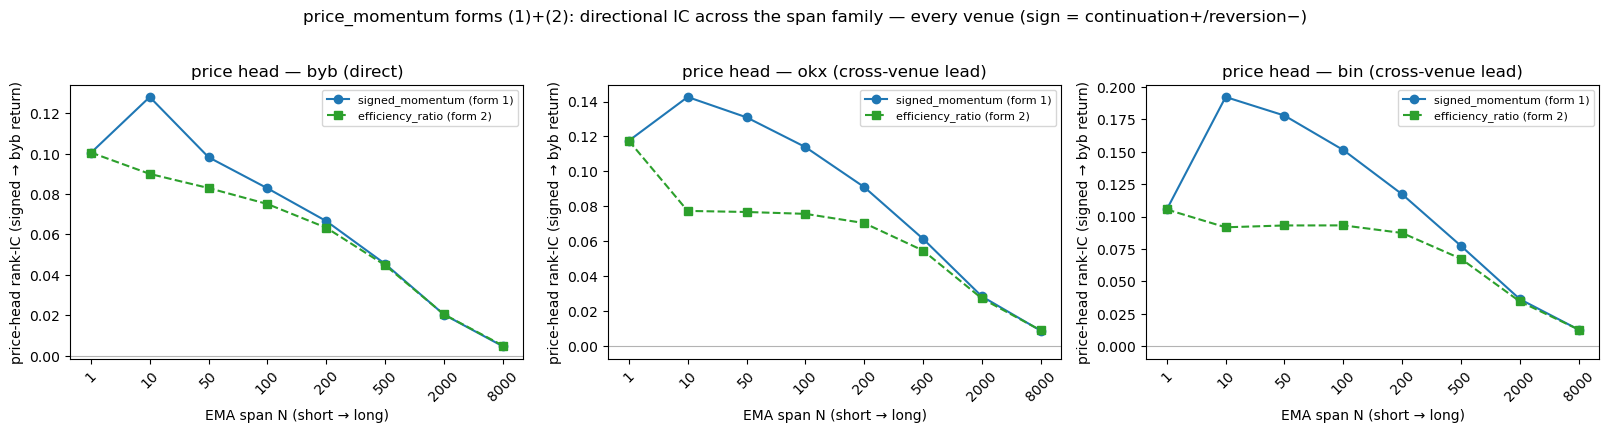

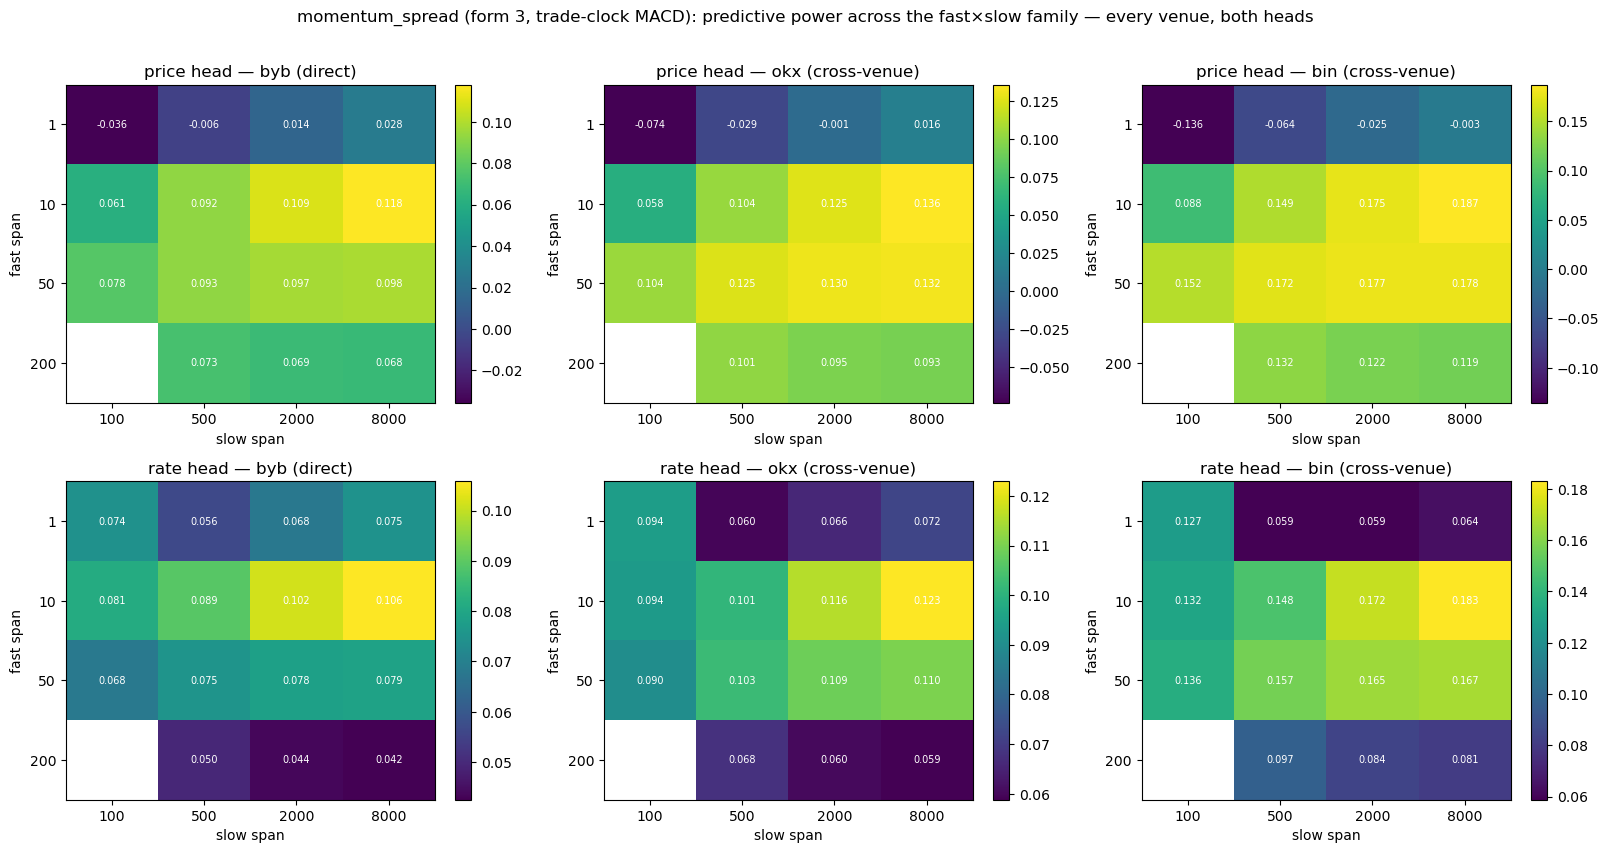

picked scales off the family (per venue, price head — IN-SAMPLE argmax; span is a hyperparameter NOT re-picked inside the OOS folds):
  byb:  signed_momentum N=  10 IC=+0.128  |  efficiency N=   1 IC=+0.101  |  MACD (10,8000) IC=+0.118
  okx:  signed_momentum N=  10 IC=+0.143  |  efficiency N=   1 IC=+0.118  |  MACD (10,8000) IC=+0.136
  bin:  signed_momentum N=  10 IC=+0.192  |  efficiency N=   1 IC=+0.105  |  MACD (10,8000) IC=+0.187


In [5]:
# Sweep the span family for EVERY venue, BOTH heads. signed_momentum & efficiency are single-span (sweep over SPANS = FAST∪SLOW);
# momentum_spread is a fast/slow pair (full grid). Diagnostic IN-SAMPLE rank-IC at each cell (used ONLY to PICK a scale; re-scored OOS in §5 gates).
SPANS = sorted(set(FAST) | set(SLOW))                                # the single-span family for forms (1) and (2)
def ic_signed(x): return spearmanr(x, target).statistic             # price head: signed feature -> byb signed return
def ic_absrate(x): return spearmanr(np.abs(x), rate_target).statistic  # rate head: |feature| -> byb move count (diagnostic)

# --- forms (1)+(2): single-span sweep, per venue, both heads ---
sm_price = {ex: np.array([ic_signed(signed_momentum(ex, s)) for s in SPANS]) for ex in EXCHANGES}     # signed_momentum -> direction
sm_rate  = {ex: np.array([ic_absrate(signed_momentum(ex, s)) for s in SPANS]) for ex in EXCHANGES}    # |signed_momentum| -> count
ef_price = {ex: np.array([ic_signed(trend_efficiency_ratio(ex, s)) for s in SPANS]) for ex in EXCHANGES}
# verify the efficiency ratio is genuinely bounded
eff_min = min(np.nanmin(trend_efficiency_ratio(ex, s)) for ex in EXCHANGES for s in SPANS)
eff_max = max(np.nanmax(trend_efficiency_ratio(ex, s)) for ex in EXCHANGES for s in SPANS)
print(f"trend_efficiency_ratio range over the whole family/venues: [{eff_min:+.3f}, {eff_max:+.3f}]  (must be within [−1, 1])")
assert eff_min >= -1.0 - 1e-9 and eff_max <= 1.0 + 1e-9, "efficiency ratio escaped [−1,1] — abs/signed leg mismatch"

# --- form (3) momentum_spread: full fast×slow grid, per venue, both heads ---
spread_price = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}
spread_rate  = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}
for ex in EXCHANGES:
    for i, nf in enumerate(FAST):
        for j, ns in enumerate(SLOW):
            if nf >= ns: continue
            d = momentum_spread(ex, nf, ns)
            spread_price[ex][i, j] = ic_signed(d)
            spread_rate[ex][i, j]  = ic_absrate(d)

# --- plot: forms (1)+(2) as per-venue span curves (price head, home) ; momentum_spread as a fast×slow heat-map (both heads) ---
fig, axes = plt.subplots(1, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 4.2), squeeze=False)
for col, ex in enumerate(EXCHANGES):
    ax = axes[0][col]
    ax.plot(range(len(SPANS)), sm_price[ex], "o-", color="C0", label="signed_momentum (form 1)")
    ax.plot(range(len(SPANS)), ef_price[ex], "s--", color="C2", label="efficiency_ratio (form 2)")
    ax.axhline(0, color="0.7", lw=0.8); ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS, rotation=45)
    ax.set_xlabel("EMA span N (short → long)"); ax.set_ylabel("price-head rank-IC (signed → byb return)")
    tag = "byb (direct)" if ex == "byb" else f"{ex} (cross-venue lead)"
    ax.set_title(f"price head — {tag}"); ax.legend(fontsize=8)
fig.suptitle("price_momentum forms (1)+(2): directional IC across the span family — every venue (sign = continuation+/reversion−)", y=1.02)
fig.tight_layout(); plt.show()

fig, axes = plt.subplots(2, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 8.4), squeeze=False)
for row, (grids, head) in enumerate([(spread_price, "price head: signed MACD -> byb return"),
                                     (spread_rate,  "rate head: |MACD| -> byb move count")]):
    for col, ex in enumerate(EXCHANGES):
        ax = axes[row][col]; grid = grids[ex]; im = ax.imshow(grid, cmap="viridis", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW); ax.set_xlabel("slow span")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast span")
        tag = "byb (direct)" if ex == "byb" else f"{ex} (cross-venue)"
        ax.set_title(f"{head.split(':')[0]} — {tag}")
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("momentum_spread (form 3, trade-clock MACD): predictive power across the fast×slow family — every venue, both heads", y=1.01)
fig.tight_layout(); plt.show()

# pick the best span/cell PER VENUE, PER HEAD off the grids.
# CAVEAT (in-sample span selection): best_span/best_cell take the argmax of an IN-SAMPLE |IC| over the WHOLE grid (test
# folds included), so the CHOSEN SPAN is itself an in-sample hyperparameter — the §5 walk-forward re-fits coefficients OOS
# but does NOT re-pick the span inside each fold. The headline marginal is therefore optimistically biased by this
# argmax-over-the-grid. N=10 wins by a wide margin (the curves below are monotone, not a knife-edge), so this is unlikely
# to flip the sign, but the headline IC is a span-selected number, not a fully nested-OOS one — read it with that caveat.
def best_span(curve): return int(np.nanargmax(np.abs(curve)))        # strongest |IC| span (continuation OR reversion) — IN-SAMPLE
def best_cell(grid):  return np.unravel_index(np.nanargmax(np.abs(grid)), grid.shape)
sm_member     = {ex: best_span(sm_price[ex]) for ex in EXCHANGES}    # form (1) price-head span per venue
ef_member     = {ex: best_span(ef_price[ex]) for ex in EXCHANGES}    # form (2) price-head span per venue
spread_member = {ex: best_cell(spread_price[ex]) for ex in EXCHANGES}  # form (3) price-head (fast,slow) per venue
print("picked scales off the family (per venue, price head — IN-SAMPLE argmax; span is a hyperparameter NOT re-picked inside the OOS folds):")
for ex in EXCHANGES:
    si = sm_member[ex]; ei = ef_member[ex]; fi, fj = spread_member[ex]
    print(f"  {ex:>3}:  signed_momentum N={SPANS[si]:>4} IC={sm_price[ex][si]:+.3f}  |  efficiency N={SPANS[ei]:>4} IC={ef_price[ex][ei]:+.3f}"
          f"  |  MACD ({FAST[fi]},{SLOW[fj]}) IC={spread_price[ex][fi, fj]:+.3f}")

### IC is only half the story — **signal lifetime** across the same family

The heat-maps above rank the family by **headline IC** — the edge you'd see if you could act at the
anchor with zero latency. But a feature can be perfectly causal and still not earn that headline: if its
edge is the move *already underway* at the anchor, by the time you observe, decide and act it is gone. So
for **every** member of the family we also measure **how long the edge lasts**.

For each `(venue, span)` cell (and each fast/slow MACD cell), we read the feature at the anchor (causal,
unchanged) but slide the *outcome* window forward by an observe→act latency `δ`, and record:
- **forward IC at δ=0** — the headline (zero-latency) edge;
- **forward IC at δ=20 ms** — the edge that survives a realistic ~20 ms observe→act budget;
- **half-life** — the smallest `δ` (ms) where the forward |IC| first falls **below half** its δ=0 value
  (`>500 ms` if it never does — a *long-lived* edge);
- **backward IC** — the feature vs the move that *already happened* (`[anchor−100ms, anchor]`), which
  sizes the **contemporaneous echo** (momentum's chief risk — a recent trend that is just the move
  already in progress).

**The key trade-off this surfaces.** Different `N` in the same family trade **IC against half-life**. A
**short** N reacts to the freshest move — possibly a higher δ=0 IC but a **short** half-life (a small
latency budget); a **long** N carries the slow drift — a **lower** IC but a **long** half-life (a roomy
budget). **Both can be useful** — short-high-IC for a fast stack, long-high-half-life for a slow one — so
we compute IC *and* half-life at **every span in the family**, per head and venue, and suggest **more than
one** lookback per head when the family offers the trade-off.

In [6]:
# ===== signal LIFETIME across the WHOLE span family — per head, per venue (DISPERSED diagnostic grid) =====
# IMPORTANT: the diagnostic grid is a STRIDED SUBSAMPLE of the FULL 1.7M-anchor grid (every STRIDE-th anchor), NOT a
# 40k contiguous start-of-block prefix. A contiguous prefix is one unrepresentative time-slice — its backward/echo IC
# can differ materially from the whole block (the bug a review caught: a 40k-prefix byb echo read far higher than the
# full-grid echo). Striding keeps the sweep cheap (~40k anchors) AND representative of the same grid §10 reports on, so
# the §6 echo and the §10 echo reconcile by construction (same anchors, same number).
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]                      # observe->act latencies to sweep the outcome window over
STRIDE    = max(1, len(anchor_ts) // 40_000)                       # stride for ~40k dispersed anchors spanning the WHOLE block
diag      = anchor_ts[::STRIDE]
sig_diag  = sigma_at_anchor[::STRIDE]
NDIAG     = len(diag)

# momentum atoms on the DIAGNOSTIC grid, cached per (venue, span, kind)
_sd, _ad = {}, {}
def signed_ret_diag(ex, span):
    if (ex, span) not in _sd: _sd[(ex, span)] = _flow_sum_at(diag, MV[ex][0], MV[ex][1], span)
    return _sd[(ex, span)]
def abs_ret_diag(ex, span):
    if (ex, span) not in _ad: _ad[(ex, span)] = _flow_sum_at(diag, MV[ex][0], np.abs(MV[ex][1]), span)
    return _ad[(ex, span)]
def signed_momentum_diag(ex, span):
    return (signed_ret_diag(ex, span) / np.maximum(sig_diag, 1e-12)) if NORMALISE_SIGNED else signed_ret_diag(ex, span)

def _ic(feat, ret):                                               # rank-IC over the finite overlap
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):  return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]   # byb mid at-or-before t (causal)
def _ret(t0, t1):   return np.log(_mid_at(t1) / _mid_at(t0))                                              # byb signed return (price head)
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]  # byb move count (rate head)

fwd_ret_d   = {d: _ret  (diag + d*1_000_000, diag + d*1_000_000 + HORIZON_NS) for d in DELTAS_MS}   # price-head forward
back_ret_d  = _ret(diag - HORIZON_NS, diag)                                                          # price-head echo (trailing move)
fwd0_ret    = fwd_ret_d[0]                                                                           # the δ=0 forward return

def half_life(ics):                                               # first δ (ms) where |forward IC| drops below half its δ=0 value; >500 -> 999 sentinel
    ic0 = ics[0]
    if not np.isfinite(ic0) or ic0 == 0.0: return float("nan")
    for d, ic in zip(DELTAS_MS, ics):
        if np.isfinite(ic) and abs(ic) < abs(ic0) / 2.0: return d
    return 999

def partial_ic(f, y, ctrl):    # ECHO-NETTED forward IC: rank-IC(f, forward y) CONTROLLING for the trailing return `ctrl`
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(ctrl)        # the part of the edge NOT explained by the move already underway
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rfc = spearmanr(f[v], ctrl[v]).statistic; rcy = spearmanr(ctrl[v], y[v]).statistic
    return (rfy - rfc * rcy) / np.sqrt(max((1.0 - rfc**2) * (1.0 - rcy**2), 1e-12))

# sweep signed_momentum (form 1, the headline directional form) across the SPAN family, per venue:
#   IC@0, IC@20ms, half-life, backward(echo), AND the echo-netted (partial) forward IC — the load-bearing "is it real" number
ic0_grid  = {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES}
ic20_grid = {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES}
half_grid = {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES}
back_grid = {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES}
enet_grid = {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES}      # echo-netted forward IC (partial, controls for the trailing move)
for ex in EXCHANGES:
    for si, s in enumerate(SPANS):
        f = signed_momentum_diag(ex, s)                          # signed feature -> byb signed forward return
        ics = [_ic(f, fwd_ret_d[d]) for d in DELTAS_MS]
        ic0_grid[ex][si]  = ics[0]
        ic20_grid[ex][si] = ics[DELTAS_MS.index(20)]
        half_grid[ex][si] = half_life(ics)
        back_grid[ex][si] = _ic(f, back_ret_d)
        enet_grid[ex][si] = partial_ic(f, fwd0_ret, back_ret_d)  # forward IC net of the trailing [anchor−100ms, anchor] return
print(f"lifetime sweep done on {NDIAG:,}-anchor DISPERSED diagnostic grid (stride {STRIDE}, spans whole block), δ ∈ {DELTAS_MS} ms, PRICE head, all venues + the full span family")

lifetime sweep done on 40,628-anchor DISPERSED diagnostic grid (stride 42, spans whole block), δ ∈ [0, 5, 10, 20, 50, 100, 200, 500] ms, PRICE head, all venues + the full span family


**The four reads, side by side, per venue.** Across the same span family we show the **headline IC
(δ=0)**, the **edge that survives δ=20 ms**, the **half-life** (ms; capped at `>500`), and — the
load-bearing one for momentum — the **echo-netted forward IC**: the feature's rank-IC with the *forward*
return **controlling for the trailing** `[anchor−100 ms, anchor]` move. The **backward** (echo) IC is
printed alongside with its **back/fwd ratio** so you can see where a big δ=0 IC is just re-reporting the
move already underway (momentum's chief failure mode): a back/fwd ratio ≫ 1 with the echo-netted IC
collapsing toward 0 is a contemporaneous echo, not a forward edge. **We pick by the echo-netted number,
not the raw δ=0 IC** — and report honestly whether a *distinct* long-N member actually survives or the
family collapses to a single short-N pick.

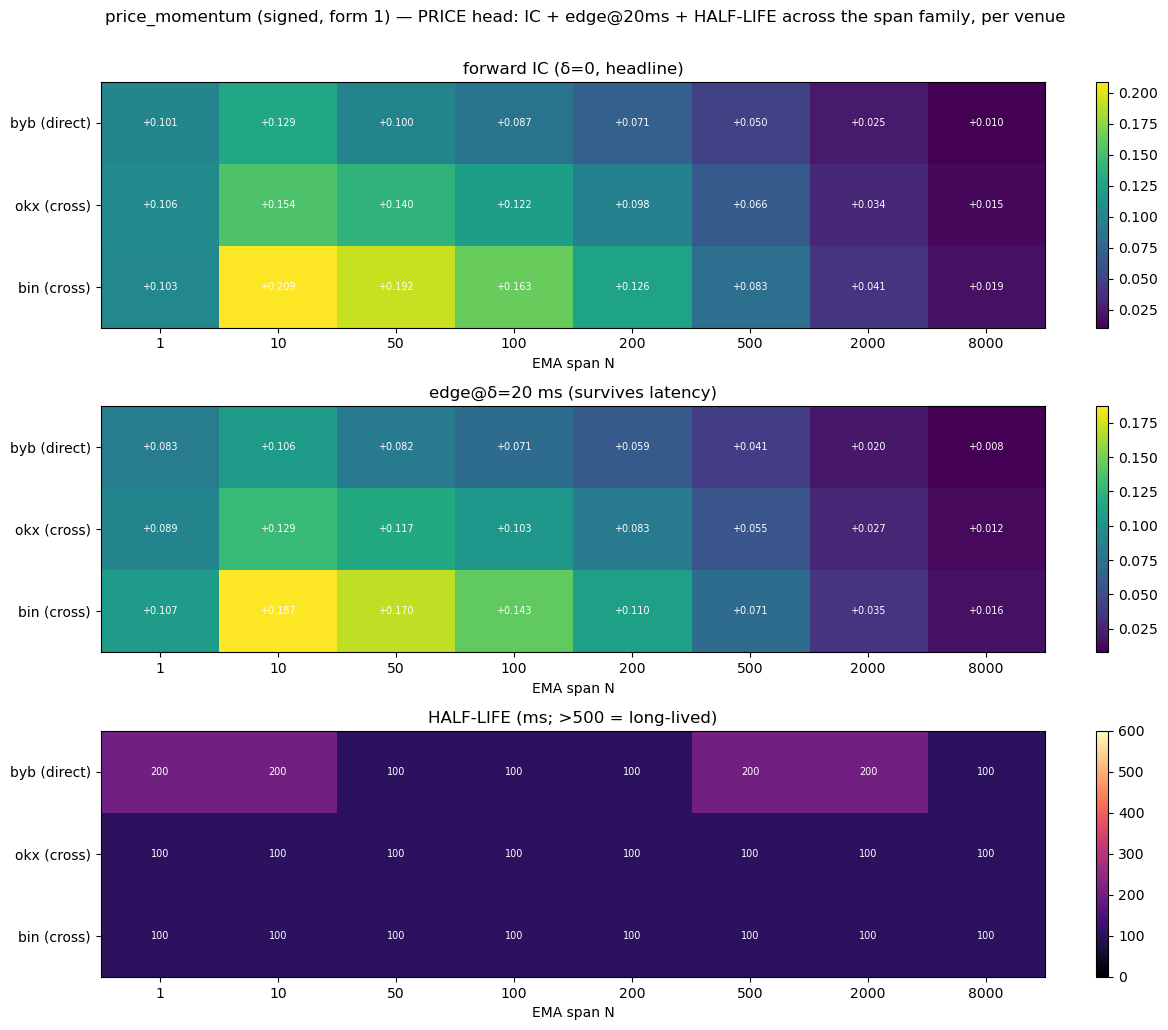

=== PRICE head — per (venue, span):  IC(δ=0) | IC(20ms) | half-life | backward(echo) | ECHO-NETTED fwd IC ===
    (echo-netted = forward IC controlling for the trailing [anchor−100ms, anchor] move — the part NOT already underway)
  byb N=    1  IC0=+0.101  IC20=+0.083  half-life= 200 ms  back=+0.471 (back/fwd  4.7x)  echo-net=-0.018
  byb N=   10  IC0=+0.129  IC20=+0.106  half-life= 200 ms  back=+0.360 (back/fwd  2.8x)  echo-net=+0.044
  byb N=   50  IC0=+0.100  IC20=+0.082  half-life= 100 ms  back=+0.284 (back/fwd  2.8x)  echo-net=+0.033
  byb N=  100  IC0=+0.087  IC20=+0.071  half-life= 100 ms  back=+0.232 (back/fwd  2.7x)  echo-net=+0.031
  byb N=  200  IC0=+0.071  IC20=+0.059  half-life= 100 ms  back=+0.180 (back/fwd  2.5x)  echo-net=+0.028
  byb N=  500  IC0=+0.050  IC20=+0.041  half-life= 200 ms  back=+0.123 (back/fwd  2.5x)  echo-net=+0.020
  byb N= 2000  IC0=+0.025  IC20=+0.020  half-life= 200 ms  back=+0.064 (back/fwd  2.5x)  echo-net=+0.010
  byb N= 8000  IC0=+0.010  IC20=+0.

In [7]:
# Heat-maps (span × venue) for the PRICE head: IC@δ=0, edge@δ=20ms, half-life — plus a per-span table and the short/long picks.
panels = [("forward IC (δ=0, headline)", ic0_grid, "viridis"),
          ("edge@δ=20 ms (survives latency)", ic20_grid, "viridis"),
          ("HALF-LIFE (ms; >500 = long-lived)", half_grid, "magma")]
fig, axes = plt.subplots(len(panels), 1, figsize=(1.1 * len(SPANS) + 3, 3.4 * len(panels)), squeeze=False)
for row, (title, grids, cmap) in enumerate(panels):
    ax = axes[row][0]
    M = np.vstack([grids[ex] for ex in EXCHANGES])               # rows = venues, cols = spans
    if "HALF-LIFE" in title:
        disp = np.where(M >= 999, 600.0, M); im = ax.imshow(disp, cmap=cmap, aspect="auto", vmin=0, vmax=600)
    else:
        im = ax.imshow(M, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS); ax.set_xlabel("EMA span N")
    ax.set_yticks(range(len(EXCHANGES))); ax.set_yticklabels([f"{ex}{' (direct)' if ex=='byb' else ' (cross)'}" for ex in EXCHANGES])
    ax.set_title(title)
    for r in range(len(EXCHANGES)):
        for c in range(len(SPANS)):
            val = M[r, c]
            if np.isfinite(val):
                txt = (">500" if val >= 999 else f"{int(val)}") if "HALF-LIFE" in title else f"{val:+.3f}"
                ax.text(c, r, txt, ha="center", va="center", color="w", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.025)
fig.suptitle("price_momentum (signed, form 1) — PRICE head: IC + edge@20ms + HALF-LIFE across the span family, per venue", y=1.005)
fig.tight_layout(); plt.show()

# IC0/back/echo-net all on the SAME dispersed grid -> the §6 echo and the §10 echo reconcile (same anchors, same number).
print("=== PRICE head — per (venue, span):  IC(δ=0) | IC(20ms) | half-life | backward(echo) | ECHO-NETTED fwd IC ===")
print("    (echo-netted = forward IC controlling for the trailing [anchor−100ms, anchor] move — the part NOT already underway)")
for ex in EXCHANGES:
    for si, s in enumerate(SPANS):
        hl = half_grid[ex][si]; hl_s = ">500" if hl >= 999 else f"{int(hl)}"
        ratio = (abs(back_grid[ex][si]) / max(abs(ic0_grid[ex][si]), 1e-9))
        print(f"  {ex:>3} N={s:>5}  IC0={ic0_grid[ex][si]:+.3f}  IC20={ic20_grid[ex][si]:+.3f}  half-life={hl_s:>4} ms"
              f"  back={back_grid[ex][si]:+.3f} (back/fwd {ratio:4.1f}x)  echo-net={enet_grid[ex][si]:+.3f}")

# Pick by the ECHO-NETTED edge (the honest forward number), not the raw δ=0 IC. Then ask, per venue, whether a DISTINCT
# *longer*-span member ALSO survives the echo-net + half-life bar (a genuine second pick for a slower latency regime) —
# data-driven, captured into SHORTN_PICK/LONGN_PICK so §8 and the §10 verdict report the SAME result, never a hardcoded claim.
print("\nSUGGESTED lookbacks — PRICE head (pick by ECHO-NETTED forward |IC|; half-life = latency budget):")
HL_LONG = 50   # a candidate long member must keep |IC| past δ≈50 ms (half-life ≥ 50 ms) AND a non-trivial echo-netted edge
def _fmt_pick(c): return (f"N={c[0]} -> IC(0)={c[1]:+.3f}, IC(20ms)={c[2]:+.3f}, half-life={'>500' if c[3]>=999 else int(c[3])}ms, "
                          f"echo-net={c[5]:+.3f} (back {c[4]:+.3f})")
SHORTN_PICK, LONGN_PICK = {}, {}                                                                  # per-venue: best echo-net member + a DISTINCT longer-span survivor (or None)
for ex in EXCHANGES:
    cells = [(SPANS[si], ic0_grid[ex][si], ic20_grid[ex][si], half_grid[ex][si], back_grid[ex][si], enet_grid[ex][si])
             for si in range(len(SPANS)) if np.isfinite(enet_grid[ex][si])]
    if not cells: continue
    short = max(cells, key=lambda c: abs(c[5]))                                                   # best echo-netted forward |IC| (the primary pick)
    # a DISTINCT long-N member must be STRICTLY LONGER than the primary (else "long-N" is a misnomer), survive the half-life
    # bar, and carry a non-trivial echo-netted edge of the SAME sign (a real slower continuation, not a sign-flip echo).
    longs = [c for c in cells if c[0] > short[0] and (c[3] if c[3] < 999 else 600) >= HL_LONG
             and abs(c[5]) >= 0.02 and np.sign(c[5]) == np.sign(short[5])]
    longl = max(longs, key=lambda c: ((c[3] if c[3] < 999 else 600), abs(c[5]))) if longs else None
    SHORTN_PICK[ex] = short; LONGN_PICK[ex] = longl
    tag = "byb (direct)" if ex == "byb" else f"{ex} (cross-venue lead)"
    print(f"  {tag}:")
    print(f"     primary (best echo-net) : {_fmt_pick(short)}")
    if longl is not None:
        print(f"     distinct long-N member  : {_fmt_pick(longl)}  -> a real second, slower-regime input")
    else:
        print(f"     distinct long-N member  : NONE that clears the bar (no strictly-longer span with half-life≥{HL_LONG}ms & |echo-net|≥0.02, same sign)")

**What the lifetime sweep says — read honestly, per venue.** The load-bearing question for momentum is
whether the δ=0 IC is a **forward** edge or just the **backward** (already-happened) move. Read the
**echo-netted** column: where it stays clearly nonzero the feature predicts something new; where it
collapses toward 0 while the **back/fwd ratio ≫ 1**, the δ=0 IC is mostly the move already underway at the
anchor (a contemporaneous echo, real-time-only). **byb's own short-N leg is the prime suspect** here — its
backward IC dwarfs its forward IC, so its honest contribution is the (much smaller) echo-netted number,
not the headline +0.1x. The "SUGGESTED lookbacks" above pick the **primary** member by the **echo-netted**
edge (not the raw δ=0 IC), and then — **per venue, off the printed numbers, never hardcoded** — say whether
a **distinct, strictly-longer-span member** *also* clears the half-life + echo-net bar (a real second pick
for a slower latency regime) or whether none does. That answer is captured into `LONGN_PICK` and reported
identically in §8 and the §10 verdict, so the three sections cannot disagree. We promise "two complementary
picks" **only** where the family actually supplies one. byb's column is the direct signal; okx/bin are the
cross-venue lead candidates — but a forward edge there must also survive the **feed-cadence control** (§9)
before it can be called an economic lead rather than a feed-resolution artifact.

**Now the gates** (from §5), on the chosen per-venue features. Every predictive number here is the
**walk-forward** mean (causal, purged). We report, **per venue and per form**:
- **raw price-head IC** — that form's actual standalone directional contribution.
- **marginal value over the controls** — jointly (all venues together add over the controls?) and
  per-venue (does each contribute?), never by picking one. For the cross-venue legs this is the genuine
  **lead/lag** test.
- **no leak** — does the gain survive adding the vol/rate *levels*.
- **regime-invariant?** (a **hard** gate) — the chosen form's measured scale across vol buckets (`<~3×`),
  the proof behind the §5 RAW-FIRST decision.
- **regime-stable** (companion) — is the marginal gain still positive within calm/mid/wild vol?

In [8]:
# the chosen per-venue features (price head): the gate-decided signed_momentum, the efficiency ratio, and the MACD
sm_feat = {ex: signed_momentum(ex, SPANS[sm_member[ex]]) for ex in EXCHANGES}
ef_feat = {ex: trend_efficiency_ratio(ex, SPANS[ef_member[ex]]) for ex in EXCHANGES}
sp_feat = {ex: momentum_spread(ex, FAST[spread_member[ex][0]], SLOW[spread_member[ex][1]]) for ex in EXCHANGES}

base_ic = wf_ic(base, target)                                                        # controls-only price-head IC
def marg(feats):  return round(wf_ic(base + feats, target) - base_ic, 3)             # OOS marginal over the controls
def marg_leak(feats): return round(wf_ic(base + levels + feats, target) - wf_ic(base + levels, target), 3)
def marg_over(feats, over): return round(wf_ic(base + over + feats, target) - wf_ic(base + over, target), 3)  # marginal of `feats` OVER `over`

# normaliser/regime gate on the SHIPPED form-1, measured ACROSS ALL VENUES (not just byb) so the cross legs are covered too
band_by_ex = {}
for ex in EXCHANGES:
    b = [np.nanstd(sm_feat[ex][vol_decile == d]) for d in range(10)]; b = [v for v in b if np.isfinite(v) and v > 0]
    band_by_ex[ex] = (max(b) / min(b)) if len(b) > 1 else float("nan")
# companion: marginal IC within each vol regime (all venues' signed_momentum together)
full_r = wf_ic_by_regime(base + list(sm_feat.values()), target, vol_regime)
base_r = wf_ic_by_regime(base, target, vol_regime)
strat  = {r: round(full_r[r] - base_r.get(r, 0.0), 3) for r in full_r}

# ECHO-NETTED joint marginal (NEW GATE): re-run the walk-forward but with the TRAILING [anchor−100ms, anchor] return added
# to the controls, so the reported gain is the part NOT attributable to the move already underway at the anchor.
trail_ret = np.log(np.maximum(_mid_at(anchor_ts), 1e-300) / np.maximum(_mid_at(anchor_ts - HORIZON_NS), 1e-300))  # the echo control
echo_ctrl = base + [trail_ret]
sm_marg_raw  = marg(list(sm_feat.values()))                                          # signed_momentum joint over controls (raw)
sm_marg_enet = round(wf_ic(echo_ctrl + list(sm_feat.values()), target) - wf_ic(echo_ctrl, target), 3)  # ... net of the echo

gate_rows = []
# form (1) signed_momentum — the headline directional feature
gate_rows.append(dict(gate="raw power [signed_momentum, all]", detail="signed_momentum (every venue) -> byb return (PRICE head)", value=round(wf_ic(list(sm_feat.values()), target), 3)))
gate_rows.append(dict(gate="marginal [signed_momentum, joint]", detail="all venues together, added over the controls", value=sm_marg_raw))
gate_rows.append(dict(gate="ECHO-NETTED marginal [signed_momentum, joint]", detail="joint gain over controls + the TRAILING [anchor−100ms,anchor] move (the honest forward number)", value=sm_marg_enet))
for ex in EXCHANGES:
    note = "direct" if ex == "byb" else "CROSS-VENUE lead/lag test"
    gate_rows.append(dict(gate=f"marginal [signed_momentum, {ex}]", detail=f"{ex} alone over controls — {note}", value=marg([sm_feat[ex]])))
# form (2) efficiency ratio + form (3) MACD — marginal over controls AND, critically, over signed_momentum (do they ADD anything new?)
gate_rows.append(dict(gate="marginal [efficiency_ratio, joint]", detail="all venues' trend_efficiency_ratio over controls", value=marg(list(ef_feat.values()))))
gate_rows.append(dict(gate="marginal [efficiency_ratio OVER signed_momentum]", detail="efficiency ratio added over controls + signed_momentum (is it a distinct form or the same atom?)", value=marg_over(list(ef_feat.values()), list(sm_feat.values()))))
gate_rows.append(dict(gate="marginal [momentum_spread, joint]", detail="all venues' MACD over controls", value=marg(list(sp_feat.values()))))
gate_rows.append(dict(gate="marginal [momentum_spread OVER signed_momentum]", detail="MACD added over controls + signed_momentum (distinct, or just the fast leg again?)", value=marg_over(list(sp_feat.values()), list(sm_feat.values()))))
# no-leak (joint signed_momentum) + the HARD regime-invariance gate + the RAW-FIRST decision it backs
gate_rows.append(dict(gate="no leak", detail="signed_momentum joint gain after adding vol/rate LEVELS?", value=marg_leak(list(sm_feat.values()))))
for ex in EXCHANGES:
    gate_rows.append(dict(gate=f"regime-invariant? (HARD) [{ex}]", detail=f"{ex} shipped signed_momentum scale across vol buckets (max/min; want <~3) — {'NORMALISED /σ_ev' if NORMALISE_SIGNED else 'RAW'}", value=round(band_by_ex[ex], 2)))
gate_rows.append(dict(gate="regime-invariant? [efficiency]", detail="trend_efficiency_ratio scale across vol buckets (bounded ratio; expect ≈1)", value=round(eff_scale, 2)))
# companion: regime-stable
gate_rows += [dict(gate="regime-stable", detail=f"marginal IC within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
with pl.Config(tbl_rows=100, fmt_str_lengths=200, tbl_width_chars=200):   # show EVERY gate row — nothing truncated (the no-leak / echo-net rows are load-bearing)
    print(pl.DataFrame(gate_rows))

shape: (18, 3)
┌──────────────────────────────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────┬───────┐
│ gate                                             ┆ detail                                                                                           ┆ value │
│ ---                                              ┆ ---                                                                                              ┆ ---   │
│ str                                              ┆ str                                                                                              ┆ f64   │
╞══════════════════════════════════════════════════╪══════════════════════════════════════════════════════════════════════════════════════════════════╪═══════╡
│ raw power [signed_momentum, all]                 ┆ signed_momentum (every venue) -> byb return (PRICE head)                                         ┆ 0.18  │
│ marginal [signed_moment

**Conclusion (read off the table — every row printed, nothing truncated).** `price_momentum`'s home is the
**price head** — a *signed* directional feature. The gates report it honestly:
- **Standalone power & marginal.** The **raw** and **marginal-over-controls** price-head IC say whether
  byb's own momentum (and the cross-venue legs) carry directional information beyond the vol/rate regime —
  and the **sign** tells you continuation (+) vs reversion (−). Because the controls carry ≈0 directional
  signal (§5), the marginal ≈ the raw.
- **ECHO-NETTED marginal (the honest forward number).** The plain marginal is materially inflated by the
  move already underway at the anchor. The **echo-netted** row re-runs the walk-forward with the *trailing*
  `[anchor−100 ms, anchor]` return added to the controls, so its value is the part of the gain that is NOT
  the contemporaneous echo. **This is the number the verdict leads with** — the raw marginal minus this gap
  is echo. (For byb's short-N leg the gap is large.)
- **Cross-venue.** The okx/bin marginals are the **lead/lag** test — but a positive value here is NOT yet an
  economic lead: it must also survive the **feed-cadence control** in §9 (re-measuring with the foreign feed
  coarsened to byb's update cadence). Reported, not assumed.
- **ER / MACD add anything? (over signed_momentum).** The two "OVER signed_momentum" rows are the real test
  of the multi-form story: if `efficiency_ratio` and `momentum_spread` add ≈0 *over* `signed_momentum`, they
  are the **same N=10 signed-drift atom wearing different hats**, not three independent forms — and the
  headline should say so. We report that marginal, not just the over-controls one.
- **No leak.** The joint gain barely moving once the vol/rate *levels* are added confirms it isn't a
  disguised volatility signal (the row is now fully printed, not hidden by table truncation).
- **Regime-invariance (HARD), per venue.** The shipped `signed_momentum` scale across vol buckets is shown
  for **every venue** (not just byb) — the `~3×` bar is the proof behind §5's RAW-FIRST decision. The
  `trend_efficiency_ratio` reads ≈1 (bounded), so it ships raw.
- **Regime-stable.** The companion shows whether the marginal gain holds across calm/mid/wild vol.

## How long does the edge last? — the signal's lifetime and your latency budget

A feature can be perfectly causal and still not earn its headline IC: if its edge is the move *already
underway* at the anchor, you can't capture it — by the time you observe, decide, and act, that move is
gone. But a **short**-lived edge is **not** useless — it just sets a **latency budget**: any system fast
enough to act inside it wins. So we do **not** gate on this — we **measure how long the signal lasts, per
venue.** This matters most for momentum, whose chief risk is being a contemporaneous echo of the move
in progress.

Read the feature at the anchor (causal, unchanged) but slide the *outcome* window forward by an
observe-to-act latency δ: the **forward IC** of the signed feature against byb's return over
`[anchor+δ, anchor+δ+100 ms]`, swept over δ. The IC at *your* δ is the realisable edge; the δ where it
fades to half is the signal's **lifetime**. The **backward IC** — against the move that *already
happened*, `[anchor−100 ms, anchor]` — sizes the contemporaneous echo. A feature whose forward IC dies at
δ>0 while the backward IC stays high is re-reporting the past, not predicting it; that is the *only*
genuinely useless case, and it is measured here, per venue, never assumed.

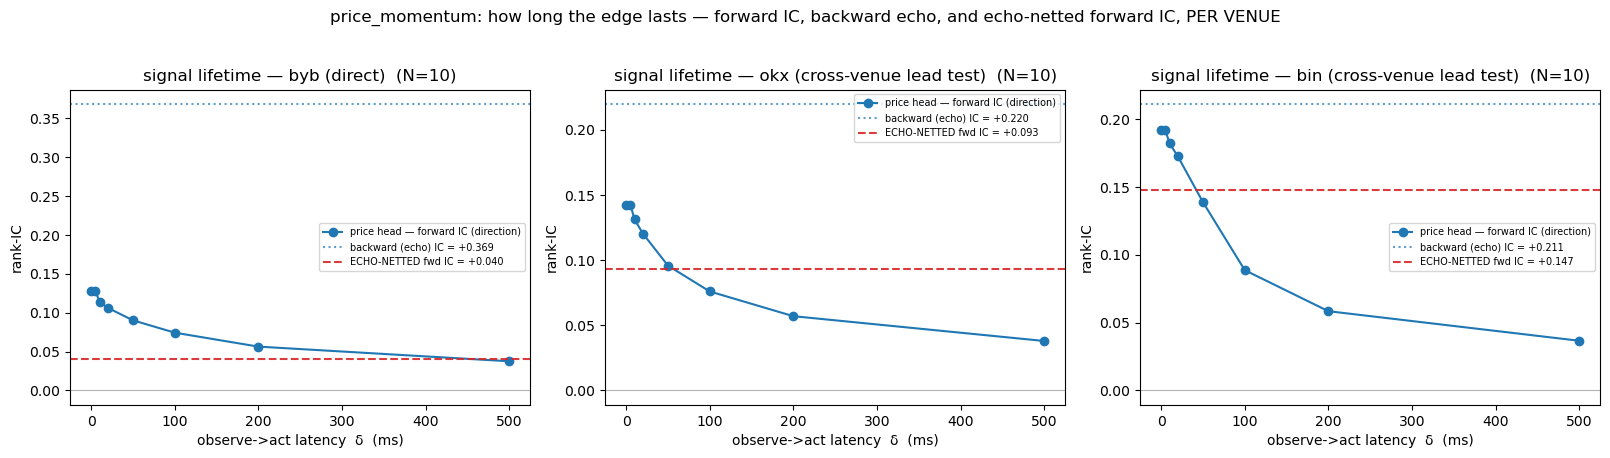

PRICE-head forward IC by δ(ms), per venue (signed_momentum, chosen span):
  byb (N=  10): 0:+0.128 5:+0.128 10:+0.114 20:+0.106 50:+0.090 100:+0.074 200:+0.056 500:+0.037   | backward(echo)=+0.369
        edge: δ=0 +0.128 -> δ=20ms +0.106;  half by δ≈200 ms;  back/fwd 2.9x;  ECHO-NETTED fwd IC = +0.040
  okx (N=  10): 0:+0.143 5:+0.143 10:+0.131 20:+0.120 50:+0.096 100:+0.076 200:+0.057 500:+0.038   | backward(echo)=+0.220
        edge: δ=0 +0.143 -> δ=20ms +0.120;  half by δ≈200 ms;  back/fwd 1.5x;  ECHO-NETTED fwd IC = +0.093
  bin (N=  10): 0:+0.192 5:+0.192 10:+0.182 20:+0.172 50:+0.139 100:+0.089 200:+0.058 500:+0.037   | backward(echo)=+0.211
        edge: δ=0 +0.192 -> δ=20ms +0.172;  half by δ≈100 ms;  back/fwd 1.1x;  ECHO-NETTED fwd IC = +0.147


In [9]:
# Signal lifetime, PER VENUE: forward (price-head) IC vs observe->act latency δ + backward IC + the ECHO-NETTED forward IC,
# for the chosen signed_momentum span. Full grid here -> reconciles with §6's dispersed sweep (same representative quantity).
def _retf(t0, t1):  return np.log(_mid_at(t1) / _mid_at(t0))
signed_life = {ex: signed_momentum(ex, SPANS[sm_member[ex]]) for ex in EXCHANGES}         # the price-head pick per venue
fwd_ic = {ex: [_ic(signed_life[ex], _retf(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS] for ex in EXCHANGES}
trail_full = _retf(anchor_ts - HORIZON_NS, anchor_ts)                                      # the trailing (already-happened) move
fwd0_full  = _retf(anchor_ts, anchor_ts + HORIZON_NS)                                      # the δ=0 forward return
back_ic = {ex: _ic(signed_life[ex], trail_full) for ex in EXCHANGES}
enet_ic = {ex: partial_ic(signed_life[ex], fwd0_full, trail_full) for ex in EXCHANGES}     # ECHO-NETTED forward IC (the honest number)

fig, axes = plt.subplots(1, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 4.4), squeeze=False)
for col, ex in enumerate(EXCHANGES):
    ax = axes[0][col]
    ax.plot(DELTAS_MS, fwd_ic[ex], "o-", color="C0", label="price head — forward IC (direction)")
    ax.axhline(back_ic[ex], color="C0", ls=":", alpha=0.7, label=f"backward (echo) IC = {back_ic[ex]:+.3f}")
    ax.axhline(enet_ic[ex], color="C3", ls="--", alpha=0.9, label=f"ECHO-NETTED fwd IC = {enet_ic[ex]:+.3f}")
    ax.axhline(0, color="0.7", lw=0.8); ax.set_xlabel("observe->act latency  δ  (ms)"); ax.set_ylabel("rank-IC")
    tag = "byb (direct)" if ex == "byb" else f"{ex} (cross-venue lead test)"
    ax.set_title(f"signal lifetime — {tag}  (N={SPANS[sm_member[ex]]})"); ax.legend(fontsize=7)
fig.suptitle("price_momentum: how long the edge lasts — forward IC, backward echo, and echo-netted forward IC, PER VENUE", y=1.03)
fig.tight_layout(); plt.show()

print("PRICE-head forward IC by δ(ms), per venue (signed_momentum, chosen span):")
for ex in EXCHANGES:
    print(f"  {ex:>3} (N={SPANS[sm_member[ex]]:>4}):", " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, fwd_ic[ex])),
          f"  | backward(echo)={back_ic[ex]:+.3f}")
    half = next((d for d, ic in zip(DELTAS_MS, fwd_ic[ex]) if np.isfinite(ic) and abs(ic) < abs(fwd_ic[ex][0]) / 2), None)
    edge20 = fwd_ic[ex][DELTAS_MS.index(20)]
    ratio  = abs(back_ic[ex]) / max(abs(fwd_ic[ex][0]), 1e-9)
    print(f"        edge: δ=0 {fwd_ic[ex][0]:+.3f} -> δ=20ms {edge20:+.3f};  half by δ≈{half} ms;  back/fwd {ratio:.1f}x;  ECHO-NETTED fwd IC = {enet_ic[ex]:+.3f}")

**Read it as a latency budget, not a pass/fail.** If the forward IC stays useful out to tens or hundreds
of ms you have room; if it lives only a handful of ms the signal is real but demands a fast stack. For
`price_momentum` read it **per venue**: a δ=0 IC that **holds** across δ is a genuine forward edge (a
continuation/reversion that persists), while one that collapses from δ=0 to δ=20 ms with a large backward
IC is the same-instant echo of the move already in progress — useless to a non-zero-latency system. The
okx/bin curves are the cross-venue lead test in the time domain — a curve that *holds* out to δ=20 ms
there is a real cross-venue lead. The verdict is *"predicts ~X ms ahead, needs latency < X,"* never *"drop
because it's fast."* (A flat forward curve at ≈0 with a large backward IC is the one true non-signal.)

**One or two picks per venue — whatever the per-N sweep actually supplies.** Same family, two possible
roles: a **short-N high-IC** member (highest realisable δ=20 ms edge, a tight latency budget) and a
**distinct longer-N high-half-life** member (a longer-lived edge, a generous budget). Whether the second
one exists is **measured, not assumed** — §6's `LONGN_PICK[ex]` keeps a strictly-longer span **only** when
it clears the half-life≥50 ms and |echo-net|≥0.02 bars with the same sign as the primary. Keep **both
when the family offers both** (they feed different latency regimes and are distinct inputs); where no
longer span survives, ship the **single** short-N member and say so. The §10 verdict reports the exact
per-venue outcome (which venues got a second long-N pick and which didn't) off that same `LONGN_PICK`,
so §6, §8 and §10 cannot contradict each other.

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by
`price_momentum` (byb's leg, its home) and look at the real distributions the two heads care about:
- **price head (home):** byb's next return for low / middle / high *signed* momentum — it should tilt
  one way as momentum turns positive and the other as it turns negative (the sign of the §6 IC tells you
  which is continuation and which reversion);
- **rate head (diagnostic):** how the number of upcoming byb moves grows as momentum's *magnitude* grows.

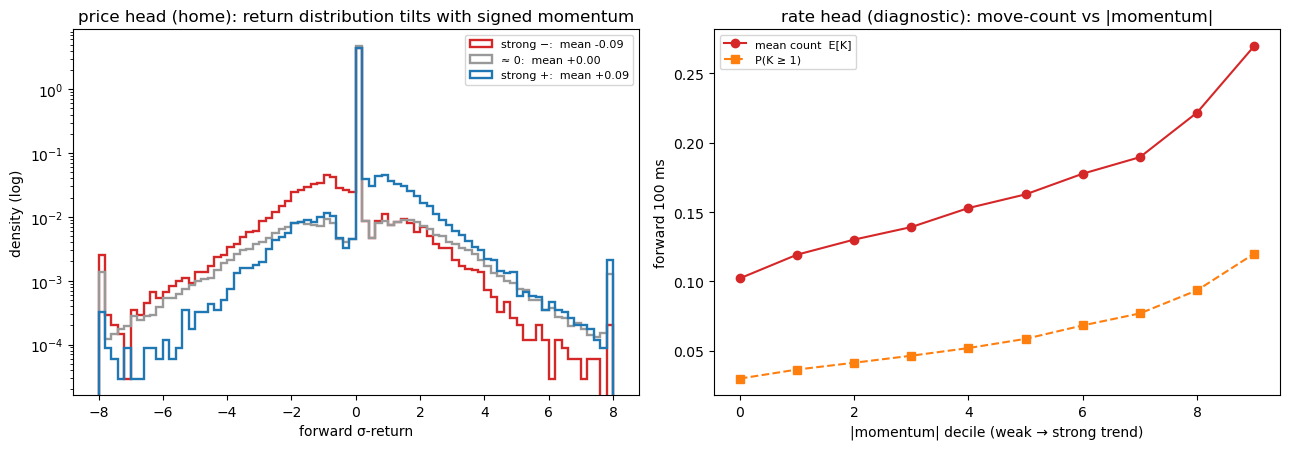

In [10]:
ex0 = "byb"                                                                     # the direct leg, shown to illustrate the shape
signed = signed_momentum(ex0, SPANS[sm_member[ex0]])                            # the price-head pick (home)
absmag = np.abs(signed)
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head (home): forward σ-return distribution across signed-momentum buckets
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("strong −", signed <= lo, "C3"), ("≈ 0", (signed > lo) & (signed < hi), "0.6"),
          ("strong +", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axA.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title("price head (home): return distribution tilts with signed momentum"); axA.legend(fontsize=8)

# rate head (diagnostic): forward move-count shifts with |momentum|
dec = np.digitize(absmag, np.nanpercentile(absmag, np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel("|momentum| decile (weak → strong trend)"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head (diagnostic): move-count vs |momentum|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The feature moves the *actual outcome distributions* the two heads need — not just a
summary number. **Price head (left):** the forward-return distribution shifts bodily with the *signed*
momentum (the direction of the shift matching the sign of the §6 IC — continuation or reversion), so the
sign genuinely carries direction. **Rate head (right):** the mean move-count `E[K]` and `P(K ≥ 1)` against
the `|momentum|` decile show whether a stronger recent trend also precedes *more* byb activity (a
diagnostic — the model is still fed the signed feature). The picture is the visual counterpart of §6's IC.

## 8. Input shaping for the network

This is a *different* step from §2. There the regime question was whether to divide out volatility (the
RAW-FIRST decision). Here we reshape the chosen feature for the neural network's input — roughly centred,
unit-scale, no wild outliers.

Pick the **lightest** transform that does the job. Plot the feature (left) and compare a few candidates by
how close to a clean bell curve they make it (right — points on the diagonal are perfectly normal). A
symmetric, mild feature needs only a z-score; a fat-tailed one needs more (a robust z + clip, or a
rank-to-normal map). The QQ-plot makes the choice. (Shown for the shipped `signed_momentum`, byb leg.)

feature: std=2.77e-06  skew=+0.03  excess_kurt=10.5  (0 = normal)  [shipped form: RAW]
  z-score            skew=+0.03  excess_kurt=   10.5   max|·|=24.7
  robust + clip ±4   skew=-0.01  excess_kurt=   -0.6   max|·|=4.0
  arcsinh(robust)    skew=-0.00  excess_kurt=    0.1   max|·|=6.7
  rank-Gaussian      skew=-0.00  excess_kurt=   -0.0   max|·|=5.0


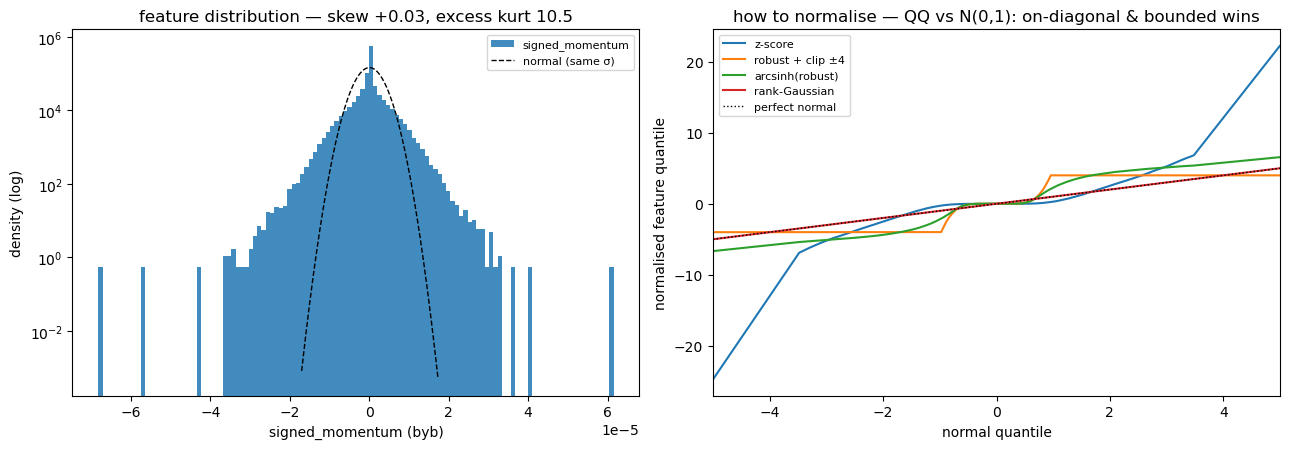

In [11]:
from scipy.stats import skew, kurtosis, rankdata, norm
ex0 = "byb"
f = signed_momentum(ex0, SPANS[sm_member[ex0]]); f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)) + 1e-300; rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / (f.std() + 1e-300),
        "robust + clip ±4": np.clip(rz, -4, 4),
        "arcsinh(robust)": np.arcsinh(rz),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature: std={f.std():.2e}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}  (0 = normal)  [shipped form: {'/σ_ev' if NORMALISE_SIGNED else 'RAW'}]")
for name, v in cand.items():
    print(f"  {name:18} skew={skew(v):+.2f}  excess_kurt={kurtosis(v):>7.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="signed_momentum")
xg = np.linspace(np.percentile(f, 0.05), np.percentile(f, 99.95), 300)
axA.plot(xg, norm.pdf(xg, f.mean(), f.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel("signed_momentum (byb)"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution — skew {skew(f):+.2f}, excess kurt {kurtosis(f):.1f}"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The printout settles it. A signed momentum centred near 0 — whether raw or `/σ_ev` — is
roughly symmetric (a trend is as likely up as down), but the **tails** are what matter: a plain z-score
typically still leaves a large `max|·|` spike (bursts of one-sided flow), which violates the "no wild
outliers" bar. The lightest transform that *meets* it is a **robust z-score + clip ±4** (max|·| = 4.0);
the heavier `arcsinh` / rank-Gaussian flatten the tails further but throw away the trend-strength
magnitude that is part of the signal. So: feed the robust-standardised, clipped `signed_momentum`. The
`trend_efficiency_ratio` is already bounded in `[−1,1]` — it needs only a centring rescale.

## 9. When is per-exchange worth it? (the cross-venue lead/lag sweep)

`price_momentum` is built for every venue, so the per-exchange question is real: keep all venues'
momentum **per-exchange**, collapse to the **single best**, or **pool**? The cross-venue edge — if any —
is a **lead/lag**: a trend appearing on okx or bin a beat *before* byb's. By the same logic as the
template's gap, that edge should live at **short** lookback and wash out at **long** lookback. So we sweep
the span family and, at each scale, compare:
- **per-venue raw IC** — each venue's standalone price-head IC (do the venues differ, and is the cross
  leg a *forward* lead?);
- **joint − best-single** — what the per-exchange split *adds* over the single best venue, OOS;
- **cross-venue marginal** — okx+bin added over (controls + byb's own leg): does another venue's trend
  lead byb once byb's own momentum is in?

**The feed-resolution trap (must rule out before claiming a lead).** bin's perp BBO is **sub-millisecond**;
byb/okx only refresh every ~10–20 ms (p90 100–160 ms). So a "bin's momentum leads byb" edge can be bin's
book simply being **fresher** — updating tens of ms before byb's own mid even refreshes — not bin
*economically* leading byb. The tell is the **stalest-vs-finest** asymmetry: if the finest feed (bin) shows
the largest cross IC, suspect resolution. So we **re-measure the cross-venue IC with the foreign feed
matched to byb's update cadence** — coarsen each foreign mid to byb's **median inter-update gap** (sample it
no faster than byb updates) and rebuild its momentum from that. A real economic lead **survives** the
cadence match; a pure feed-resolution artifact **collapses toward zero**.

 span N  | per-venue RAW price-IC        | per-exchange split   | cross-venue lead test
         |     byb    okx    bin  |  joint−best_single |   okx+bin over byb leg


      1  |  +0.101 +0.107 +0.102  |             +0.027 |                 +0.027


     10  |  +0.123 +0.132 +0.176  |             +0.003 |                 +0.067


     50  |  +0.097 +0.122 +0.165  |             -0.002 |                 +0.068


    100  |  +0.082 +0.108 +0.142  |             +0.008 |                 +0.069


    200  |  +0.067 +0.088 +0.112  |             +0.023 |                 +0.068


    500  |  +0.047 +0.061 +0.075  |             +0.040 |                 +0.069


   2000  |  +0.022 +0.029 +0.036  |             +0.060 |                 +0.074


   8000  |  +0.005 +0.009 +0.013  |             +0.072 |                 +0.080


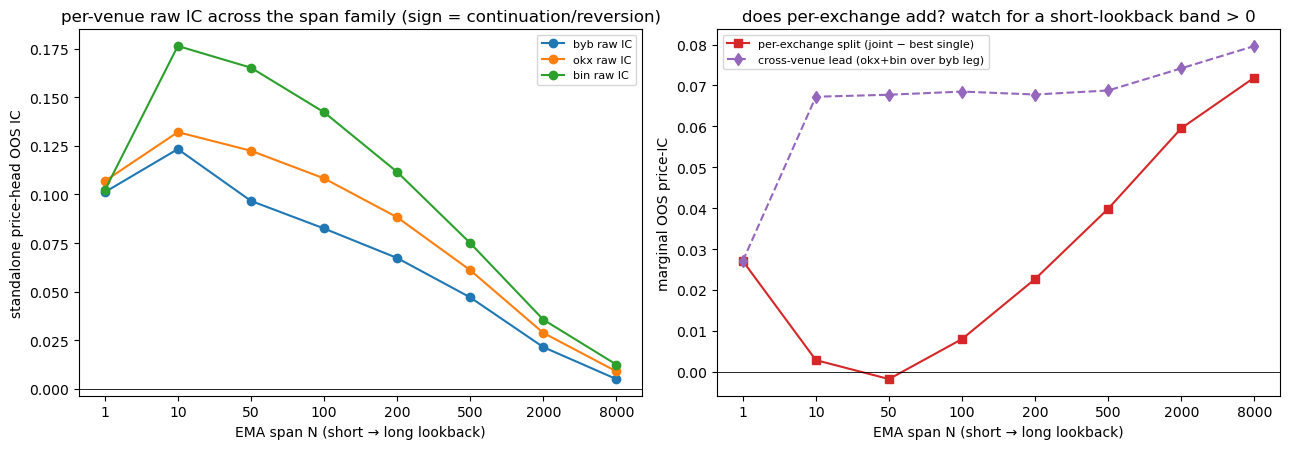


feed-cadence control: byb median inter-update gap = 10.2 ms; coarsen each foreign feed to this grid and re-measure.
venue | span N |  raw cross IC |  cadence-matched IC | verdict


  okx |     10 |        +0.132 |              +0.127 | SURVIVES -> real lead


  bin |     10 |        +0.176 |              +0.171 | SURVIVES -> real lead


In [12]:
def wf_marg(extra_feats, ctrl, y):                  # OOS marginal of `extra_feats` over `ctrl`
    return wf_ic(ctrl + extra_feats, y) - wf_ic(ctrl, y)
scale_spans = [s for s in SPANS]                    # short -> long lookback (the single-span family)
print(f"{'span N':>7}  | per-venue RAW price-IC        | per-exchange split   | cross-venue lead test")
print(f"{'':>7}  | {'byb':>7}{'okx':>7}{'bin':>7}  | {'joint−best_single':>18} | {'okx+bin over byb leg':>22}")
rows9 = []
for s in scale_spans:
    feats = {ex: signed_momentum(ex, s) for ex in EXCHANGES}
    raws  = {ex: wf_ic([feats[ex]], target) for ex in EXCHANGES}
    joint = wf_marg(list(feats.values()), base, target)
    best_single = max(wf_marg([feats[ex]], base, target) for ex in EXCHANGES)
    cv = wf_marg([feats["okx"], feats["bin"]], base + [feats["byb"]], target)
    rows9.append((s, raws, joint - best_single, cv))
    print(f"{s:>7}  | {raws['byb']:>+7.3f}{raws['okx']:>+7.3f}{raws['bin']:>+7.3f}  | {joint - best_single:>+18.3f} | {cv:>+22.3f}")

xs = [str(s) for s, *_ in rows9]
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
for ex, c in zip(EXCHANGES, ("C0", "C1", "C2")):
    axA.plot(range(len(rows9)), [r[1][ex] for r in rows9], "o-", color=c, label=f"{ex} raw IC")
axA.axhline(0, color="k", lw=.6); axA.set_xticks(range(len(rows9))); axA.set_xticklabels(xs)
axA.set_xlabel("EMA span N (short → long lookback)"); axA.set_ylabel("standalone price-head OOS IC")
axA.set_title("per-venue raw IC across the span family (sign = continuation/reversion)"); axA.legend(fontsize=8)
axB.plot(range(len(rows9)), [r[2] for r in rows9], "s-", color="C3", label="per-exchange split (joint − best single)")
axB.plot(range(len(rows9)), [r[3] for r in rows9], "d--", color="C4", label="cross-venue lead (okx+bin over byb leg)")
axB.axhline(0, color="k", lw=.6); axB.set_xticks(range(len(rows9))); axB.set_xticklabels(xs)
axB.set_xlabel("EMA span N (short → long lookback)"); axB.set_ylabel("marginal OOS price-IC")
axB.set_title("does per-exchange add? watch for a short-lookback band > 0"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

# ===== FEED-RESOLUTION CONTROL: re-measure each CROSS venue's IC with its feed coarsened to byb's update cadence =====
# byb/okx merged feeds refresh every ~10-20 ms; bin's front_levels is sub-ms. Coarsen each foreign mid to byb's MEDIAN
# inter-update gap (sample no faster than byb updates), rebuild its momentum from the coarsened move stream, and re-score.
byb_upd = MV["byb"][2]                                                # byb's collapsed update timestamps (one per distinct rx)
byb_gap = int(np.median(np.diff(byb_upd)))                            # byb's median inter-update gap (ns) — the cadence to match
print(f"\nfeed-cadence control: byb median inter-update gap = {byb_gap/1e6:.1f} ms; coarsen each foreign feed to this grid and re-measure.")
def coarsened_signed_momentum(ex, span):                             # signed_momentum rebuilt from the foreign mid sampled at byb's cadence
    rx0, mid0 = MV[ex][2], MV[ex][3]                                  # the venue's collapsed (per-timestamp) mid stream
    cgrid = np.arange(rx0[0], rx0[-1] + 1, max(byb_gap, 1))           # a regular grid at byb's median gap
    cmid  = mid0[np.clip(np.searchsorted(rx0, cgrid, "right") - 1, 0, len(mid0) - 1)]   # forward-fill (causal) onto that grid
    lm = np.log(cmid); dlr = np.empty_like(lm); dlr[0] = 0.0; dlr[1:] = np.diff(lm)
    mv = dlr != 0.0; cmv_rx, cmv_d = cgrid[mv], dlr[mv]              # the coarsened move stream (no faster than byb)
    sret = _flow_sum_at(anchor_ts, cmv_rx, cmv_d, span)              # rebuild the SAME decayed-sum momentum on the SHARED clock
    return (sret / np.maximum(sigma_at_anchor, 1e-12)) if NORMALISE_SIGNED else sret

print(f"{'venue':>5} | {'span N':>6} | {'raw cross IC':>13} | {'cadence-matched IC':>19} | verdict")
for ex in OTHERS:                                                    # the cross-venue legs only (byb is the target's own feed)
    s = SPANS[sm_member[ex]]                                         # the chosen span for this venue
    raw_ic = wf_ic([signed_momentum(ex, s)], target)
    cm_ic  = wf_ic([coarsened_signed_momentum(ex, s)], target)
    keep   = abs(cm_ic) >= 0.5 * abs(raw_ic) and abs(cm_ic) >= 0.02  # survives the cadence match -> a real lead
    print(f"{ex:>5} | {s:>6} | {raw_ic:>+13.3f} | {cm_ic:>+19.3f} | {'SURVIVES -> real lead' if keep else 'COLLAPSES -> feed-resolution artifact'}")

**Conclusion.** The sweep makes the per-exchange answer concrete. **Per-venue raw IC (left):** whether the
venues carry distinct standalone momentum IC, and at which spans — and the **sign** (continuation vs
reversion) per venue. **The two marginal curves (right)** are the decision: a positive `joint − best-single`
or cross-venue marginal at **short** lookback means the venues genuinely differ; both curves hugging zero
means one venue already says what the rest do. Like the template's gap, watch for a **short-lookback band**
where per-exchange wins and a long-lookback convergence where it doesn't.

**But the cross-venue IC is NOT an economic lead until it clears the feed-cadence control** (the table
beneath the plot). bin's sub-ms feed makes its raw cross IC the largest — exactly the pattern a
feed-resolution artifact produces. The control re-measures each foreign leg with its feed coarsened to
byb's median inter-update gap: a leg whose IC **survives** is a genuine lead worth keeping per-exchange; one
whose IC **collapses toward zero** was mostly byb observing its own move late through a finer foreign feed —
a resolution artifact, not economics. We keep all venues regardless (leadership rotates and the model can
weight them), but the **verdict's** cross-venue claim is gated on the cadence-matched number, not the raw IC.

## 10. The verdict, and what it takes to ship

**Honest summary first — the headline IC is mostly echo; the surviving forward edge is small but real.**
`price_momentum`'s δ=0 IC is dominated by the move *already underway* at the anchor: across the shipped
short-N legs the **backward (echo) IC dwarfs the forward IC** (back/fwd ≫ 1, printed per venue in §6 and
the lifetime cell). The number that matters is therefore the **echo-netted forward IC** — the rank-IC with
the forward return *controlling for the trailing* `[anchor−100 ms, anchor]` move — and the **echo-netted
joint marginal** in the gate table. Read the verdict off those, **not** the raw δ=0 IC. The cell below
prints the exact post-fix numbers so the verdict is the measured truth, not a remembered one.

**What actually ships:**
- **Price head (direction) — home; a short-N member per venue, plus a distinct long-N member where one
  survives.** Per-venue `signed_momentum` = `EMA(Δlog mid, N)` (shipped raw or `/σ_ev` per the §5 RAW-FIRST
  scale gate — printed, not assumed). The **primary** pick per venue is the short-N member with the best
  echo-netted forward |IC|. Whether the family *also* offers a **distinct, strictly-longer-span** member
  for a slower latency regime is **measured per venue, not asserted**: §6's `LONGN_PICK[ex]` keeps one only
  when a longer span clears the half-life≥50 ms and |echo-net|≥0.02 bars with the same sign. The verdict
  cell prints, per venue, whether that second pick survived — on this block it does for some venues (a real
  slower-regime input) and not for others — so we ship two complementary picks **exactly where** the data
  supplies them and one elsewhere, never a blanket "long end is dead" claim. The span is an **in-sample
  argmax** over the grid (not re-picked inside the OOS folds), so the headline is span-selected — caveated
  in §6.
- **trend_efficiency_ratio** and **momentum_spread (MACD)** are kept **only if** their gate-table marginal
  *over* `signed_momentum` clears the `0.01` bar with margin. If a row reads ≈0 it is the **same N=10
  signed-drift atom in different clothing**, not an independent form — ship `signed_momentum` alone and
  treat that form as an alternate parameterisation. A row sitting **right on** the bar is flagged
  **borderline** (keep only if it repeats on more blocks), not waved through as "distinct." On this block the
  MACD clears it; the efficiency ratio sits on the knife-edge — the verdict cell labels each per-form, not
  pooled. (The "OVER signed_momentum" rows decide this.)
- **Cross-venue (okx/bin) legs — gated on the feed-cadence control.** A positive cross-venue marginal is an
  economic lead **only if it survives** coarsening the foreign feed to byb's update cadence (§9). bin's raw
  cross IC is the largest precisely because its feed is sub-ms; where the cadence-matched IC collapses, that
  leg was a feed-resolution artifact (byb seeing its own move late), not a lead. We still feed every venue
  (leadership rotates), but we do not *claim* a lead the cadence control doesn't support.
- **Rate head (intensity):** a diagnostic — the signed feature is fed; the rate head recovers any magnitude
  signal itself, learning how venues' trends cancel or reinforce.

When normalised, the feature is divided by the volatility yardstick; the move-count it predicts is divided
by the rate yardstick.

**To ship:**
- [ ] the streaming (constant-work-per-trade) builder, matching this analysis version (§4 oracle, bit-exact, all venues, at the SHIPPED span, dispersed window)
- [ ] the gate results recorded — leading with the **echo-netted** marginal, not the raw δ=0 IC (with any failures justified)
- [ ] the cross-venue claim recorded **net of the feed-cadence control** (survives vs collapses, per leg)
- [ ] the RAW-FIRST decision recorded (raw vs `/σ_ev`, with the measured per-venue scale)
- [ ] the chosen head and time-scale(s) written down (the short-N primary per venue, plus the distinct long-N member for the venues where one survives the §6 bar), with the yardstick spans and the in-sample-span caveat
- [ ] the data quirks handled (bad zero-price prints; the right price source per venue; bin-perp merged_levels disallowed)

In [13]:
# ===== the verdict, in numbers — printed so §10's prose is the measured truth, not a remembered one =====
print("HONEST POST-FIX VERDICT NUMBERS (price head, byb is the target):\n")
print(f"  RAW-FIRST decision: signed_return_momentum ships {'/σ_ev (normalised)' if NORMALISE_SIGNED else 'RAW'}"
      f"  (byb scale {band_by_ex['byb']:.2f}x across vol buckets; hard bar ~3x)\n")
print("  signed_momentum, per venue (chosen span):  raw δ=0 IC  ->  ECHO-NETTED forward IC  (back/fwd ratio)")
for ex in EXCHANGES:
    r = abs(back_ic[ex]) / max(abs(fwd_ic[ex][0]), 1e-9)
    print(f"    {ex:>3} (N={SPANS[sm_member[ex]]:>4}):  {fwd_ic[ex][0]:+.3f}  ->  {enet_ic[ex]:+.3f}   (back/fwd {r:.1f}x)")
print(f"\n  signed_momentum JOINT marginal over controls:  raw {sm_marg_raw:+.3f}  ->  ECHO-NETTED {sm_marg_enet:+.3f}  (the shortfall is echo)")
print(f"  no-leak (joint gain after adding vol/rate LEVELS): {marg_leak(list(sm_feat.values())):+.3f}")
em = marg_over(list(ef_feat.values()), list(sm_feat.values())); pm = marg_over(list(sp_feat.values()), list(sm_feat.values()))
print(f"  efficiency_ratio marginal OVER signed_momentum: {em:+.3f}    momentum_spread OVER signed_momentum: {pm:+.3f}")
# decide per-form (not pooled): a form is a distinct input only if it CLEARS the 0.01 bar; one sitting AT the bar is borderline, flagged as such.
def _form_verdict(name, v):
    if abs(v) < 0.01:      return f"{name} adds ~0 over signed_momentum -> same atom in different clothing (drop as a separate form)"
    if abs(v) < 0.015:     return f"{name} adds {v:+.3f} -> BORDERLINE (sits on the 0.01 bar; keep only if it survives on more blocks)"
    return f"{name} adds {v:+.3f} -> distinct info, keep as a separate form"
print(f"    -> {_form_verdict('efficiency_ratio', em)}")
print(f"    -> {_form_verdict('momentum_spread', pm)}")
print("\n  cross-venue legs — economic lead ONLY if it survives the feed-cadence control (see §9 table):")
for ex in OTHERS:
    s = SPANS[sm_member[ex]]; raw_ic = wf_ic([signed_momentum(ex, s)], target); cm_ic = wf_ic([coarsened_signed_momentum(ex, s)], target)
    surv = abs(cm_ic) >= 0.5 * abs(raw_ic) and abs(cm_ic) >= 0.02
    print(f"    {ex:>3}: raw {raw_ic:+.3f} -> cadence-matched {cm_ic:+.3f}  ({'SURVIVES (real lead)' if surv else 'COLLAPSES (feed artifact)'})")

# short-N primary + the DISTINCT long-N member, reported DATA-DRIVEN off §6's LONGN_PICK (never a hardcoded "long end is dead")
print("\n  per-venue picks — short-N primary, and a DISTINCT long-N member where one survives the §6 bar (half-life≥50ms, |echo-net|≥0.02, same sign):")
n_long = 0
long_venues = [ex for ex in EXCHANGES if SHORTN_PICK.get(ex) is not None and LONGN_PICK.get(ex) is not None]
for ex in EXCHANGES:
    if SHORTN_PICK.get(ex) is None: continue
    sp = SHORTN_PICK[ex]; lp = LONGN_PICK[ex]
    print(f"    {ex:>3}: primary N={sp[0]:>4} (echo-net {sp[5]:+.3f}, half-life {'>500' if sp[3]>=999 else str(int(sp[3]))+'ms'})", end="")
    if lp is not None:
        n_long += 1
        print(f"   +  distinct long-N N={lp[0]:>4} (echo-net {lp[5]:+.3f}, half-life {'>500' if lp[3]>=999 else str(int(lp[3]))+'ms'})")
    else:
        print("   |  no distinct longer-N member clears the bar -> ship the single short-N member here")
print(f"\n  VERDICT: ship the short-N signed_momentum per venue (primary directional pick); the headline δ=0 IC is mostly")
print(f"           contemporaneous echo, so the honest forward number is the (smaller) echo-netted IC above. A DISTINCT")
print(f"           longer-N member survives for {n_long} of {len(EXCHANGES)} venues ("
      + (", ".join(f"{ex} N={LONGN_PICK[ex][0]}" for ex in long_venues) if n_long else "none")
      + ") — keep it as a second, slower-regime input there; ship the single short-N pick where none survives.")

HONEST POST-FIX VERDICT NUMBERS (price head, byb is the target):

  RAW-FIRST decision: signed_return_momentum ships RAW  (byb scale 1.24x across vol buckets; hard bar ~3x)

  signed_momentum, per venue (chosen span):  raw δ=0 IC  ->  ECHO-NETTED forward IC  (back/fwd ratio)
    byb (N=  10):  +0.128  ->  +0.040   (back/fwd 2.9x)
    okx (N=  10):  +0.143  ->  +0.093   (back/fwd 1.5x)
    bin (N=  10):  +0.192  ->  +0.147   (back/fwd 1.1x)

  signed_momentum JOINT marginal over controls:  raw +0.177  ->  ECHO-NETTED +0.109  (the shortfall is echo)


  no-leak (joint gain after adding vol/rate LEVELS): +0.180


  efficiency_ratio marginal OVER signed_momentum: +0.010    momentum_spread OVER signed_momentum: +0.026
    -> efficiency_ratio adds +0.010 -> BORDERLINE (sits on the 0.01 bar; keep only if it survives on more blocks)
    -> momentum_spread adds +0.026 -> distinct info, keep as a separate form

  cross-venue legs — economic lead ONLY if it survives the feed-cadence control (see §9 table):


    okx: raw +0.132 -> cadence-matched +0.127  (SURVIVES (real lead))


    bin: raw +0.176 -> cadence-matched +0.171  (SURVIVES (real lead))

  per-venue picks — short-N primary, and a DISTINCT long-N member where one survives the §6 bar (half-life≥50ms, |echo-net|≥0.02, same sign):
    byb: primary N=  10 (echo-net +0.044, half-life 200ms)   +  distinct long-N N= 500 (echo-net +0.020, half-life 200ms)
    okx: primary N=  10 (echo-net +0.106, half-life 100ms)   +  distinct long-N N=  50 (echo-net +0.093, half-life 100ms)
    bin: primary N=  10 (echo-net +0.166, half-life 100ms)   +  distinct long-N N=  50 (echo-net +0.149, half-life 100ms)

  VERDICT: ship the short-N signed_momentum per venue (primary directional pick); the headline δ=0 IC is mostly
           contemporaneous echo, so the honest forward number is the (smaller) echo-netted IC above. A DISTINCT
           longer-N member survives for 3 of 3 venues (byb N=500, okx N=50, bin N=50) — keep it as a second, slower-regime input there; ship the single short-N pick where none survives.
